<a href="https://colab.research.google.com/github/AntonDozhdikov/politpredict/blob/main/political_system_marl_v5_github_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MARL-моделирование политических систем — v5 (GPU-ускоренная версия)
## MARL Modelling of Political Systems — v5 (GPU-accelerated)

**Алгоритм / Algorithm:** MAPPO, схема CTDE  
**Страны / Countries:** США, Франция, Германия, Россия, Япония, Индия, Китай

---

### Что изменилось относительно v4 / Changes vs v4

| Оптимизация | Где применена | Эффект |
|---|---|---|
| `torch.amp` (AMP/FP16) + `GradScaler` | `MAPPOTrainer.update()` | ~1.5–2× на T4 |
| Батчевый инференс всех ролей за 1 forward | `_policy()` | ×N_roles меньше вызовов |
| Rollout-буфер в `torch.Tensor` (pre-alloc) | `RolloutBuffer` | устранены `np.stack` в update |
| `role_onehot` кэширован на GPU | `__init__` | убраны пересоздания в цикле |
| `optimizer.zero_grad(set_to_none=True)` | `update()` | снижение overhead |
| `torch.backends.cudnn.benchmark = True` | init | авто-оптимизация ядер |
| `non_blocking=True` при переносе тензоров | `update()` | перекрытие CPU↔GPU transfer |
| **Единый прогресс-бар всего эксперимента** | `run_experiment()` | удобный мониторинг |
| `tqdm.set_postfix` с live-метриками | inner loop | виден rew/kl/ent в реальном времени |

**Архитектура, метрики, протокол, формулы и выводы — идентичны v4.**

---

| # | Раздел |
|---|---|
| 1 | Зависимости и настройка GPU |
| 2 | Постановка задачи (формулы LaTeX) |
| 3 | Индикаторы, роли, действия |
| 4 | Мягкие границы и гомеостаз |
| 5 | Конфигурации семи стран |
| 6 | Шоки |
| 7 | Среда CountryEnv |
| 8 | Базовые политики |
| 9 | MAPPO v5: AMP + батчевый инференс |
| 10 | Обучение: ранняя остановка |
| 11 | Диагностика сходимости |
| 12 | Полный эксперимент + единый прогресс-бар |
| 13 | Агрегация и таблицы |
| 14 | Визуализация (Ч/Б, Полис) |
| 15а | Excel-книги |
| 15б | Архив результатов |
| 16 | Объективная проверка |
| 17 | Интерпретация и ограничения |

## 1. Зависимости и настройка GPU / Dependencies and GPU Setup

Все пакеты входят в стандартную сборку Google Colab.  
Для T4: Runtime → Change runtime type → GPU.  
*All packages are standard in Colab. For T4: Runtime → Change runtime type → GPU.*

In [ ]:
!pip -q install torch numpy pandas matplotlib tqdm openpyxl

import os, io, json, math, time, random, zipfile, datetime, glob, shutil, warnings
from dataclasses import dataclass, field
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
from tqdm.auto import tqdm
from openpyxl import Workbook
from openpyxl.styles import Font, Alignment, PatternFill, Border, Side
from openpyxl.utils import get_column_letter

warnings.filterwarnings("ignore", category=UserWarning)

print(f"PyTorch : {torch.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"Pandas  : {pd.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {DEVICE}")

# Авто-оптимизация CUDA-ядер для стабильных размеров тензоров.
# Auto-tune CUDA kernels for stable tensor shapes.
torch.backends.cudnn.benchmark = True

# AMP доступен только на CUDA; на CPU — no-op.
# AMP is only active on CUDA; on CPU it's a no-op.
USE_AMP = DEVICE.type == "cuda"
print(f"AMP     : {USE_AMP}")


def set_seed(seed: int) -> None:
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

PyTorch : 2.11.0+cu128
NumPy   : 2.0.2
Pandas  : 2.2.2
CUDA    : True
Device  : cuda
AMP     : True


## 2. Постановка задачи / Problem Statement

### Марковская игра / Markov Game

$$\mathcal{G} = \langle \mathcal{N},\, \mathcal{S},\, \{\mathcal{O}_i\},\, \{\mathcal{A}_i\},\, \mathcal{T},\, \{R_i\} \rangle$$

Локальное наблюдение агента:

$$o_i = [s;\,\mathrm{one\text{-}hot}(\mathrm{role}_i)]$$

### PPO Objective

$$L^{\text{CLIP}}(\theta) = \mathbb{E}_t\!\left[\min\!\left(r_t(\theta)\hat{A}_t,\;\operatorname{clip}(r_t(\theta),1-\varepsilon,1+\varepsilon)\hat{A}_t\right)\right]$$

$$r_t(\theta)= \frac{\pi_\theta(a_t \mid o_t)}{\pi_{\theta_\text{old}}(a_t \mid o_t)}$$

### GAE

$$\hat{A}_t = \sum_{l \ge 0} (\gamma\lambda)^l \delta_{t+l}, \qquad \delta_t = r_t + \gamma V_\phi(s_{t+1}) - V_\phi(s_t)$$

### Полная функция потерь / Full Loss

$$\mathcal{L}(\theta,\phi) = L^{\text{CLIP}}(\theta) + c_v \cdot L^{\text{value}}(\phi) - c_e \cdot H[\pi_\theta]$$

### Сравнение алгоритмов / Algorithm Comparison

| Критерий | MAPPO | MADDPG |
|---|---|---|
| Тип действий | Дискретные | Непрерывные |
| Критик | $V(s)$ скаляр | $Q(s,a_{1..n})$ |
| Стабильность | On-policy + KL-стоп | Off-policy, replay |
| AMP | Да (v5) | Сложнее (Gumbel) |

## 3. Индикаторы, роли и действия / State Indicators, Roles, Actions

| Индикатор | Интерпретация | Направление |
|---|---|---|
| economy | Экономическое развитие | high = better |
| social_trust | Общественное доверие | high = better |
| legitimacy | Легитимность власти | high = better |
| adaptivity | Адаптивность системы | high = better |
| inequality | Неравенство | **high = worse** |
| polarization | Политическая поляризация | **high = worse** |
| external_pressure | Внешнее давление | **high = worse** |
| tech_modern | Технологическая модернизация | high = better |
| feedback_quality | Качество обратной связи | high = better |
| admin_capacity | Административный потенциал | high = better |
| innovation | Инновационность | high = better |

In [ ]:
STATE_INDICATORS = [
    "economy","social_trust","legitimacy","adaptivity","inequality",
    "polarization","external_pressure","tech_modern","feedback_quality",
    "admin_capacity","innovation",
]
N_IND = len(STATE_INDICATORS)
IDX   = {n: i for i, n in enumerate(STATE_INDICATORS)}

ROLE_CATALOG = [
    "executive","bureaucracy","legislature","business","civil",
    "media","regional","geopolitics","judiciary","security","technocrats",
]
N_ROLES  = len(ROLE_CATALOG)
ROLE_IDX = {r: i for i, r in enumerate(ROLE_CATALOG)}

ACTION_CATALOG = [
    "redistribution","reform","regulation","communication","coalition",
    "mobilization","innovation","foreign_response","economic_stimulus",
    "security_measure","feedback","status_quo",
]
N_ACT = len(ACTION_CATALOG)
ACT   = {a: i for i, a in enumerate(ACTION_CATALOG)}

STATE_RU_SHORT = {
    "economy":"Экономика","social_trust":"Доверие","legitimacy":"Легитимность",
    "adaptivity":"Адаптивность","inequality":"Неравенство","polarization":"Поляризация",
    "external_pressure":"Внеш.давл.","tech_modern":"Тех.мод.",
    "feedback_quality":"Обр.связь","admin_capacity":"Адм.пот.","innovation":"Инновации",
}
STATE_EN_SHORT = {
    "economy":"Economy","social_trust":"Trust","legitimacy":"Legitimacy",
    "adaptivity":"Adaptivity","inequality":"Inequality","polarization":"Polarization",
    "external_pressure":"Ext.pr.","tech_modern":"Tech.mod.",
    "feedback_quality":"Feedback","admin_capacity":"Admin.cap.","innovation":"Innovation",
}
print(f"Indicators: {N_IND}  Roles: {N_ROLES}  Actions: {N_ACT}")

Indicators: 11  Roles: 11  Actions: 12


## 4. Мягкие границы и гомеостаз / Soft Bounds and Homeostasis

$$\mathrm{soft}(x) = 0.02 + 0.96\cdot\sigma(3.2(x-0.5))$$

$$\Delta s^{\text{homeo}}_t = 0.008\,(0.5 - s_t)$$

In [ ]:
SOFT_LO, SOFT_HI = 0.02, 0.98
HOMEOSTASIS_TARGET, HOMEOSTASIS_RATE = 0.5, 0.008

def soft_bound(x: np.ndarray) -> np.ndarray:
    k = 3.2
    return (SOFT_LO + (SOFT_HI-SOFT_LO)/(1.0+np.exp(-k*(x-0.5)))).astype(np.float32)

def rolling_mean(x, w):
    x = np.asarray(x, float)
    if len(x) < w: return np.array([np.mean(x[:i+1]) for i in range(len(x))])
    return np.convolve(x, np.ones(w)/w, mode="valid")

print("soft_bound test:", np.round(soft_bound(np.array([0.,0.5,1.])),4))

soft_bound test: [0.1813 0.5    0.8187]


## 5. Конфигурации семи стран / Country Configurations

Параметры — синтетические экспертные оценки, не реальные данные.  
*All parameters are synthetic expert estimates.*

In [ ]:
@dataclass
class CountryConfig:
    name: str; name_ru: str; roles: List[str]
    init_state: Dict[str,float]; reward_weights: Dict[str,float]
    shock_sensitivity: float=1.0; centralization: float=0.5
    alpha: float=1.0; beta: float=1.0; gamma: float=1.0

def _rw(**kw):
    b=dict(stability=1.,development=1.,adaptivity=1.,legitimacy=1.,feedback=1.)
    b.update(kw); return b

def build_country_configs():
    c={}
    c["USA"]=CountryConfig("USA","США",
        ["executive","legislature","judiciary","business","media","civil","regional","geopolitics"],
        dict(economy=0.66,social_trust=0.52,legitimacy=0.56,adaptivity=0.58,inequality=0.52,
             polarization=0.62,external_pressure=0.46,tech_modern=0.74,feedback_quality=0.56,
             admin_capacity=0.62,innovation=0.72),_rw(development=1.15,legitimacy=1.05),0.9,0.35)
    c["France"]=CountryConfig("France","Франция",
        ["executive","bureaucracy","legislature","business","civil","media","geopolitics"],
        dict(economy=0.60,social_trust=0.48,legitimacy=0.52,adaptivity=0.54,inequality=0.44,
             polarization=0.54,external_pressure=0.42,tech_modern=0.68,feedback_quality=0.56,
             admin_capacity=0.68,innovation=0.62),_rw(feedback=1.15,stability=1.05),1.0,0.60)
    c["Germany"]=CountryConfig("Germany","Германия",
        ["executive","bureaucracy","legislature","business","civil","regional","technocrats","geopolitics"],
        dict(economy=0.68,social_trust=0.58,legitimacy=0.62,adaptivity=0.60,inequality=0.38,
             polarization=0.42,external_pressure=0.44,tech_modern=0.72,feedback_quality=0.64,
             admin_capacity=0.74,innovation=0.66),_rw(stability=1.2,adaptivity=1.1),0.85,0.48)
    c["Russia"]=CountryConfig("Russia","Россия",
        ["executive","bureaucracy","security","business","regional","media","civil","geopolitics"],
        dict(economy=0.54,social_trust=0.46,legitimacy=0.56,adaptivity=0.44,inequality=0.56,
             polarization=0.50,external_pressure=0.70,tech_modern=0.56,feedback_quality=0.40,
             admin_capacity=0.62,innovation=0.52),_rw(stability=1.3,legitimacy=1.15,adaptivity=0.85),1.1,0.82)
    c["Japan"]=CountryConfig("Japan","Япония",
        ["executive","bureaucracy","legislature","business","civil","technocrats","geopolitics"],
        dict(economy=0.62,social_trust=0.60,legitimacy=0.60,adaptivity=0.52,inequality=0.40,
             polarization=0.36,external_pressure=0.52,tech_modern=0.78,feedback_quality=0.60,
             admin_capacity=0.76,innovation=0.66),_rw(stability=1.15,development=1.1),0.9,0.56)
    c["India"]=CountryConfig("India","Индия",
        ["executive","bureaucracy","legislature","judiciary","business","civil","regional","media","geopolitics"],
        dict(economy=0.58,social_trust=0.50,legitimacy=0.54,adaptivity=0.52,inequality=0.62,
             polarization=0.56,external_pressure=0.48,tech_modern=0.54,feedback_quality=0.50,
             admin_capacity=0.48,innovation=0.60),_rw(development=1.25,feedback=1.1),1.05,0.45)
    c["China"]=CountryConfig("China","Китай",
        ["executive","bureaucracy","security","business","regional","technocrats","civil","geopolitics"],
        dict(economy=0.70,social_trust=0.54,legitimacy=0.58,adaptivity=0.54,inequality=0.52,
             polarization=0.40,external_pressure=0.64,tech_modern=0.72,feedback_quality=0.44,
             admin_capacity=0.78,innovation=0.70),_rw(development=1.25,stability=1.2,feedback=0.9),1.0,0.85)
    return c

COUNTRY_CONFIGS = build_country_configs()
RU = {c: cfg.name_ru for c, cfg in COUNTRY_CONFIGS.items()}
rows=[{"Страна/Country":cfg.name_ru,"Ролей":len(cfg.roles),
       "economy_0":round(cfg.init_state["economy"],2),
       "legitimacy_0":round(cfg.init_state["legitimacy"],2),
       "inequality_0":round(cfg.init_state["inequality"],2),
       "Centr.":cfg.centralization,"Shock":cfg.shock_sensitivity}
      for cfg in COUNTRY_CONFIGS.values()]
pd.DataFrame(rows).set_index("Страна/Country")

,Ролей,economy_0,legitimacy_0,inequality_0,Centr.,Shock
Страна/Country,,,,,,
США,8,0.66,0.56,0.52,0.35,0.90
Франция,7,0.60,0.52,0.44,0.60,1.00
Германия,8,0.68,0.62,0.38,0.48,0.85
Россия,8,0.54,0.56,0.56,0.82,1.10
Япония,7,0.62,0.60,0.40,0.56,0.90
Индия,9,0.58,0.54,0.62,0.45,1.05
Китай,8,0.70,0.58,0.52,0.85,1.00


## 6. Внешние шоки / External Shocks

$p_{\text{shock}} = 0.05 \cdot \delta_{\text{country}}$ на каждом шаге.

In [ ]:
SHOCK_TYPES = {
    "geopolitical":    {"external_pressure":+0.18,"economy":-0.04,"legitimacy":-0.02},
    "economic_crisis": {"economy":-0.18,"social_trust":-0.06,"inequality":+0.06},
    "polarization":    {"polarization":+0.18,"social_trust":-0.05,"legitimacy":-0.03},
    "tech_shock":      {"tech_modern":+0.12,"innovation":+0.10,"admin_capacity":-0.03},
    "trust_crisis":    {"social_trust":-0.15,"legitimacy":-0.12,"feedback_quality":-0.06},
}
print("Shock types:", list(SHOCK_TYPES.keys()))

Shock types: ['geopolitical', 'economic_crisis', 'polarization', 'tech_shock', 'trust_crisis']


## 7. Среда CountryEnv / Environment

$$s_{t+1} = \mathrm{soft}\!\left(s_t + \Delta^{\text{act}}_t + \Delta^{\text{nat}}(s_t) + \varepsilon_t + \Delta^{\text{shock}}_t\right)$$

$$r_t = \frac{\sum_k w_k m_k(s_t)}{\sum_k w_k} - 0.25\,s[\text{inequality}] - 0.5\,C(s_t)$$

In [ ]:
ACTION_EFFECTS = {
    "redistribution":    {"inequality":-0.060,"social_trust":+0.034,"economy":-0.018},
    "reform":            {"adaptivity":+0.058,"admin_capacity":+0.026,"legitimacy":-0.010,"polarization":+0.016},
    "regulation":        {"admin_capacity":+0.036,"innovation":-0.022,"polarization":-0.016},
    "communication":     {"legitimacy":+0.034,"feedback_quality":+0.038,"social_trust":+0.022},
    "coalition":         {"polarization":-0.050,"legitimacy":+0.024,"adaptivity":+0.016},
    "mobilization":      {"polarization":+0.044,"social_trust":+0.016,"legitimacy":+0.008},
    "innovation":        {"innovation":+0.058,"tech_modern":+0.046,"economy":+0.030,"inequality":+0.012},
    "foreign_response":  {"external_pressure":-0.058,"economy":-0.012,"legitimacy":+0.012},
    "economic_stimulus": {"economy":+0.050,"inequality":+0.012,"admin_capacity":-0.008},
    "security_measure":  {"polarization":-0.028,"admin_capacity":+0.024,"feedback_quality":-0.020},
    "feedback":          {"feedback_quality":+0.054,"adaptivity":+0.024,"legitimacy":+0.016},
    "status_quo":        {"adaptivity":-0.020,"economy":+0.008},
}

class CountryEnv:
    def __init__(self,cfg,horizon,seed):
        self.cfg=cfg; self.horizon=horizon; self.roles=cfg.roles
        self.n_agents=len(cfg.roles); self.rng=np.random.RandomState(seed); self.reset()
    def reset(self):
        self.t=0; self.last_shock=""
        self.state=np.array([self.cfg.init_state[k] for k in STATE_INDICATORS],dtype=np.float32)
        return self.state.copy()
    def _apply_actions(self,actions):
        d=np.zeros(N_IND,dtype=np.float32)
        for role,a in zip(self.roles,actions):
            for ind,dd in ACTION_EFFECTS[ACTION_CATALOG[a]].items():
                m=1.0
                if   role=="business"    and ind in("economy","innovation"):           m=1.4
                elif role=="security"    and ind in("polarization","admin_capacity"):  m=1.4
                elif role=="technocrats" and ind in("innovation","tech_modern"):       m=1.4
                elif role=="civil"       and ind in("feedback_quality","social_trust"):m=1.3
                elif role=="media"       and ind in("feedback_quality","polarization"):m=1.3
                elif role=="geopolitics" and ind=="external_pressure":                 m=1.5
                d[IDX[ind]]+=dd*m
        d/=max(1.,0.5*self.n_agents); return d*self.cfg.alpha
    def _natural(self,s):
        n=np.zeros(N_IND,dtype=np.float32)
        n[IDX["economy"]]          +=0.012*(s[IDX["innovation"]]-0.5)-0.018*(s[IDX["external_pressure"]]-0.5)
        n[IDX["legitimacy"]]       +=0.016*(s[IDX["feedback_quality"]]-0.5)-0.016*(s[IDX["polarization"]]-0.5)
        n[IDX["social_trust"]]     +=0.014*(s[IDX["legitimacy"]]-0.5)
        n[IDX["adaptivity"]]       +=0.008*(s[IDX["innovation"]]-0.5)
        n[IDX["polarization"]]     +=0.008*(s[IDX["inequality"]]-0.5)
        n[IDX["external_pressure"]]-=0.010
        cz=self.cfg.centralization
        n[IDX["polarization"]]-=0.006*cz; n[IDX["feedback_quality"]]-=0.006*cz
        n+=HOMEOSTASIS_RATE*(HOMEOSTASIS_TARGET-s); return n*self.cfg.beta
    def _contradiction_penalty(self,s):
        rl=lambda x:max(0.,x)
        li=self.legitimacy_index(s); di=self.development_index(s); si=self.stability_index(s)
        p =rl(li-0.6)*rl(s[IDX["inequality"]]-0.6)*1.6
        p+=rl(li-0.6)*rl(s[IDX["polarization"]]-0.6)*1.4
        p+=rl(di-0.6)*rl(0.4-s[IDX["feedback_quality"]])*1.4
        p+=rl(di-0.6)*rl(0.4-s[IDX["adaptivity"]])*1.2
        p+=rl(si-0.6)*rl(0.4-li)*1.5
        p+=rl(si-0.6)*rl(s[IDX["external_pressure"]]-0.7)*1.2
        return float(p)
    def step(self,actions):
        s=self.state
        raw=s+self._apply_actions(actions)+self._natural(s)+self.rng.normal(0,0.004,N_IND).astype(np.float32)
        self.last_shock=""
        if self.rng.rand()<0.05*self.cfg.shock_sensitivity:
            st=self.rng.choice(list(SHOCK_TYPES.keys()))
            for ind,d in SHOCK_TYPES[st].items(): raw[IDX[ind]]+=d*self.cfg.shock_sensitivity
            self.last_shock=st
        self.state=soft_bound(raw); rew,comps=self._reward(self.state)
        self.t+=1; return self.state.copy(),rew,self.t>=self.horizon,{"shock":self.last_shock,"components":comps}
    @staticmethod
    def stability_index(s):
        return float(np.clip(0.5*(1-s[IDX["polarization"]])+0.25*(1-s[IDX["external_pressure"]])+0.25*s[IDX["social_trust"]],0,1))
    @staticmethod
    def development_index(s):
        return float(np.clip(0.5*s[IDX["economy"]]+0.3*s[IDX["tech_modern"]]+0.2*s[IDX["innovation"]],0,1))
    @staticmethod
    def adaptivity_index(s):
        return float(np.clip(0.6*s[IDX["adaptivity"]]+0.4*s[IDX["admin_capacity"]],0,1))
    @staticmethod
    def legitimacy_index(s):
        return float(np.clip(0.6*s[IDX["legitimacy"]]+0.4*s[IDX["social_trust"]],0,1))
    @staticmethod
    def feedback_index(s):
        return float(np.clip(s[IDX["feedback_quality"]],0,1))
    def _reward(self,s):
        w=self.cfg.reward_weights
        comps=dict(stability=self.stability_index(s),development=self.development_index(s),
                   adaptivity=self.adaptivity_index(s),legitimacy=self.legitimacy_index(s),
                   feedback=self.feedback_index(s))
        base=sum(w[k]*comps[k] for k in comps)/sum(w.values())
        iq=0.25*s[IDX["inequality"]]; cp=self._contradiction_penalty(s)
        comps.update(base=float(base),inequality_penalty=float(iq),contradiction_penalty=float(cp))
        r=(base-iq-0.5*cp)*self.cfg.gamma; comps["reward"]=float(r)
        return float(r),comps

print("CountryEnv ready.")

CountryEnv ready.


## 8. Базовые политики / Baseline Policies

In [ ]:
class RandomPolicy:
    def __init__(self,env,seed=0): self.env=env; self.rng=np.random.RandomState(seed)
    def act(self,state): return [int(self.rng.randint(N_ACT)) for _ in self.env.roles]

class HeuristicPolicy:
    def __init__(self,env,seed=0): self.env=env; self.rng=np.random.RandomState(seed)
    def act(self,state):
        s=state; acts=[]
        for role in self.env.roles:
            if   s[IDX["external_pressure"]]>0.6: a="foreign_response" if role=="geopolitics" else "security_measure"
            elif s[IDX["polarization"]]>0.6:      a="coalition" if role in("legislature","executive") else "communication"
            elif s[IDX["economy"]]<0.45:          a="economic_stimulus" if role in("executive","business") else "reform"
            elif s[IDX["feedback_quality"]]<0.45: a="feedback" if role in("media","civil") else "communication"
            elif s[IDX["inequality"]]>0.6:        a="redistribution"
            else: a=self.rng.choice(["innovation","reform","communication","coalition"])
            acts.append(ACT[a])
        return acts

def evaluate_policy(policy,env,n_ep):
    rewards,finals=[],[]
    for _ in range(n_ep):
        state=env.reset(); ep_r=0.
        while True:
            ns,r,done,_=env.step(policy.act(state)); ep_r+=r; state=ns
            if done: break
        rewards.append(ep_r); finals.append(env.state.copy())
    S=np.mean(np.stack(finals),axis=0)
    return dict(mean_reward=float(np.mean(rewards)),std_reward=float(np.std(rewards)),
                final_state=S,stability=CountryEnv.stability_index(S),
                development=CountryEnv.development_index(S),
                adaptation=CountryEnv.adaptivity_index(S),
                legitimacy=CountryEnv.legitimacy_index(S),
                feedback=CountryEnv.feedback_index(S))

print("Baselines ready.")

Baselines ready.


## 9. MAPPO v5: AMP + батчевый инференс / MAPPO v5: AMP + Batched Inference

### Ключевые изменения относительно v4 / Key changes vs v4

1. **`torch.amp.autocast`** оборачивает forward actor + critic — FP16 на T4 Tensor Cores.  
2. **`GradScaler`** масштабирует loss во избежание underflow при FP16.  
3. **`_policy()`** вычисляет действия всех ролей **одним** `forward`-вызовом (`[n_roles, obs_dim]`).  
4. **`RolloutBuffer`** хранит данные в pre-allocated `torch.Tensor` → убирает `np.stack` в `update()`.  
5. **`role_onehot`** создается один раз на GPU и переиспользуется.  
6. **`zero_grad(set_to_none=True)`** снижает memory-overhead обнуления.  
7. **`non_blocking=True`** при переносе tensor'ов на device.

Архитектура сетей, PPO-алгоритм, GAE, раняя остановка — **не изменены**.

In [ ]:
@dataclass
class MAPPOConfig:
    hidden_dim:int=256; lr_actor:float=3e-4; lr_critic:float=1e-3
    gamma:float=0.97; lambda_gae:float=0.95; epsilon_clip:float=0.20
    c_value:float=0.50; c_entropy:float=0.01; n_ppo_epochs:int=4
    batch_size:int=64; rollout_len:int=256; max_grad_norm:float=0.5

class PolicyNet(nn.Module):
    def __init__(self, obs_dim, act_dim, h):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, act_dim)
        )

    def forward(self, x):
        return self.net(x)

    def action_dist(self, x):
        return torch.distributions.Categorical(logits=self.forward(x))

class ValueNet(nn.Module):
    def __init__(self, s_dim, h):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(s_dim, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

class WelfordNorm:
    def __init__(self):
        self.n = 0
        self.mean = 0.
        self.M2 = 0.

    def update(self, x):
        self.n += 1
        d = x - self.mean
        self.mean += d / self.n
        self.M2 += d * (x - self.mean)

    def std(self):
        return math.sqrt(self.M2 / max(1, self.n - 1) + 1e-8)

    def normalize(self, x):
        return (x - self.mean) / max(self.std(), 1e-8)

class RolloutBuffer:
    """Pre-allocated tensor buffer. Убирает np.stack в update()."""
    def __init__(self, rollout_len, n_roles, obs_dim, state_dim, device):
        self.T = rollout_len
        self.nr = n_roles
        self.device = device
        self.obs   = torch.zeros(rollout_len, n_roles, obs_dim, device=device)
        self.gs    = torch.zeros(rollout_len, state_dim, device=device)
        self.acts  = torch.zeros(rollout_len, n_roles, dtype=torch.long, device=device)
        self.lps   = torch.zeros(rollout_len, n_roles, device=device)
        self.rews  = torch.zeros(rollout_len, device=device)
        self.vals  = torch.zeros(rollout_len, device=device)
        self.dones = torch.zeros(rollout_len, device=device)
        self.ptr = 0

    def push(self, obs_t, gs_t, acts_t, lps_t, rew, val, done):
        i = self.ptr
        self.obs[i] = obs_t
        self.gs[i] = gs_t
        self.acts[i] = acts_t
        self.lps[i] = lps_t
        self.rews[i] = rew
        self.vals[i] = val
        self.dones[i] = done
        self.ptr += 1

    def full(self):
        return self.ptr >= self.T

    def reset(self):
        self.ptr = 0

class MAPPOAgent:
    """v5: AMP + batched role inference + pre-alloc buffer."""
    def __init__(self, env, cfg, device):
        self.env = env
        self.cfg = cfg
        self.device = device
        self.amp_device = "cuda" if device.type == "cuda" else "cpu"

        obs_dim = N_IND + N_ROLES
        self.actor  = PolicyNet(obs_dim, N_ACT, cfg.hidden_dim).to(device)
        self.critic = ValueNet(N_IND, cfg.hidden_dim).to(device)

        self.opt_a = torch.optim.Adam(self.actor.parameters(), lr=cfg.lr_actor)
        self.opt_c = torch.optim.Adam(self.critic.parameters(), lr=cfg.lr_critic)

        self.scaler_a = torch.amp.GradScaler(self.amp_device, enabled=USE_AMP)
        self.scaler_c = torch.amp.GradScaler(self.amp_device, enabled=USE_AMP)

        n_roles = len(env.roles)
        role_idx = torch.tensor([ROLE_IDX[r] for r in env.roles], device=device)
        self.role_oh = torch.zeros(n_roles, N_ROLES, device=device)
        self.role_oh.scatter_(1, role_idx.unsqueeze(1), 1.0)

        self.buf = RolloutBuffer(cfg.rollout_len, n_roles, obs_dim, N_IND, device)
        self.norm = WelfordNorm()
        self._best_val = -1e9
        self._bwa = None
        self._bwc = None

    def _make_obs(self, state_t):
        s = state_t.unsqueeze(0).expand(len(self.env.roles), -1)
        return torch.cat([s, self.role_oh], dim=1)

    @torch.no_grad()
    def act(self, state_np):
        s = torch.tensor(state_np, dtype=torch.float32, device=self.device)
        obs = self._make_obs(s)

        with torch.amp.autocast(device_type=self.amp_device, enabled=USE_AMP):
            dist = self.actor.action_dist(obs)
        acts = dist.sample()
        lps = dist.log_prob(acts)

        with torch.amp.autocast(device_type=self.amp_device, enabled=USE_AMP):
            val = self.critic(s.unsqueeze(0)).item()

        return acts, lps, float(val), obs, s

    def store(self, obs_t, gs_t, acts_t, lps_t, reward, val, done):
        self.norm.update(reward)
        r = torch.tensor(self.norm.normalize(reward), dtype=torch.float32, device=self.device)
        v = torch.tensor(val, dtype=torch.float32, device=self.device)
        d = torch.tensor(float(done), dtype=torch.float32, device=self.device)
        self.buf.push(obs_t, gs_t, acts_t, lps_t, r, v, d)

    def update(self):
        b = self.buf
        T = b.ptr
        if T == 0:
            return {}

        obs    = b.obs[:T]
        gs     = b.gs[:T]
        acts   = b.acts[:T]
        old_lp = b.lps[:T]

        rews  = b.rews[:T].detach().cpu().numpy()
        vals  = b.vals[:T].detach().cpu().numpy()
        dones = b.dones[:T].detach().cpu().numpy()

        adv = np.zeros(T, dtype=np.float32)
        last = 0.0
        for i in reversed(range(T)):
            nv = vals[i + 1] if i + 1 < T else 0.0
            d = rews[i] + self.cfg.gamma * nv * (1.0 - dones[i]) - vals[i]
            last = d + self.cfg.gamma * self.cfg.lambda_gae * (1.0 - dones[i]) * last
            adv[i] = last

        ret = adv + vals
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        adv_t = torch.from_numpy(adv).to(self.device, dtype=torch.float32, non_blocking=True)
        ret_t = torch.from_numpy(ret).to(self.device, dtype=torch.float32, non_blocking=True)
        old_vals_t = b.vals[:T].clone()

        logs = {"pg": [], "vl": [], "ent": [], "kl": []}

        for _ in range(self.cfg.n_ppo_epochs):
            idx = torch.randperm(T, device=self.device)
            for s in range(0, T, self.cfg.batch_size):
                bi = idx[s:s + self.cfg.batch_size]

                self.opt_a.zero_grad(set_to_none=True)
                self.opt_c.zero_grad(set_to_none=True)

                with torch.amp.autocast(device_type=self.amp_device, enabled=USE_AMP):
                    dist = self.actor.action_dist(obs[bi])
                    lp = dist.log_prob(acts[bi])
                    ent = dist.entropy().mean()

                    ratio = (lp - old_lp[bi]).exp()
                    a_mb = adv_t[bi].unsqueeze(1)

                    pg = -torch.min(
                        ratio * a_mb,
                        ratio.clamp(1 - self.cfg.epsilon_clip, 1 + self.cfg.epsilon_clip) * a_mb
                    ).mean()

                    vp = self.critic(gs[bi])
                    vc = old_vals_t[bi] + (
                        vp.detach() - old_vals_t[bi]
                    ).clamp(-self.cfg.epsilon_clip, self.cfg.epsilon_clip)

                    vl = 0.5 * torch.max(
                        (vp - ret_t[bi]).pow(2),
                        (vc - ret_t[bi]).pow(2)
                    ).mean()

                    loss_a = pg - self.cfg.c_entropy * ent
                    loss_c = self.cfg.c_value * vl

                self.scaler_a.scale(loss_a).backward(retain_graph=True)
                self.scaler_c.scale(loss_c).backward()

                self.scaler_a.unscale_(self.opt_a)
                self.scaler_c.unscale_(self.opt_c)

                nn.utils.clip_grad_norm_(self.actor.parameters(), self.cfg.max_grad_norm)
                nn.utils.clip_grad_norm_(self.critic.parameters(), self.cfg.max_grad_norm)

                self.scaler_a.step(self.opt_a)
                self.scaler_c.step(self.opt_c)
                self.scaler_a.update()
                self.scaler_c.update()

                with torch.no_grad():
                    kl = (old_lp[bi] - lp).mean().item()

                logs["pg"].append(float(pg))
                logs["vl"].append(float(vl))
                logs["ent"].append(float(ent))
                logs["kl"].append(float(kl))

        self.buf.reset()
        return {k: float(np.mean(v)) for k, v in logs.items()}

    def save_best(self, val):
        if val > self._best_val:
            self._best_val = val
            self._bwa = {k: v.detach().cpu().clone() for k, v in self.actor.state_dict().items()}
            self._bwc = {k: v.detach().cpu().clone() for k, v in self.critic.state_dict().items()}

    def load_best(self):
        if self._bwa is not None:
            self.actor.load_state_dict({k: v.to(self.device) for k, v in self._bwa.items()})
            self.critic.load_state_dict({k: v.to(self.device) for k, v in self._bwc.items()})

print("MAPPOAgent v5 fixed and ready.")

MAPPOAgent v5 fixed and ready.


## 10. Обучение: ранняя остановка и лучший чекпойнт / Training

Ранняя остановка: $\text{MA}_{10}$, ожидание 15 обновлений, $\Delta < 10^{-3}$.  
*Early stopping: MA10, patience 15 updates, tolerance 1e-3.*

In [ ]:
def train_single(cfg_c,mcfg,horizon,n_updates,seed,pbar=None):
    """Обучает MAPPO-агента (v5). pbar — внешний tqdm для update-level postfix."""
    set_seed(seed)
    env=CountryEnv(cfg_c,horizon,seed); agent=MAPPOAgent(env,mcfg,DEVICE)
    ep_rewards,pg_hist,vl_hist,ent_hist,kl_hist=[],[],[],[],[]
    state=env.reset(); ep_r=0.; best_ma=-1e9; patience=0
    PATIENCE=15; MA_W=10
    for upd in range(n_updates):
        for _ in range(mcfg.rollout_len):
            acts,lps,val,obs_t,gs_t=agent.act(state)
            ns,r,done,_=env.step(acts.tolist())
            agent.store(obs_t,gs_t,acts,lps,r,val,done)
            ep_r+=r; state=ns
            if done: ep_rewards.append(ep_r); ep_r=0.; state=env.reset()
        logs=agent.update()
        if logs:
            pg_hist.append(logs.get("pg",0)); vl_hist.append(logs.get("vl",0))
            ent_hist.append(logs.get("ent",0)); kl_hist.append(logs.get("kl",0))
        if len(ep_rewards)>=MA_W:
            ma=float(np.mean(ep_rewards[-MA_W:])); agent.save_best(ma)
            if ma>best_ma+1e-3: best_ma=ma; patience=0
            else: patience+=1
            if patience>=PATIENCE: break
        if pbar is not None:
            pbar.update(1)
            if logs: pbar.set_postfix({"rew":f"{(ep_rewards[-1] if ep_rewards else 0):.3f}",
                                        "kl":f"{logs.get('kl',0):.3f}",
                                        "ent":f"{logs.get('ent',0):.2f}"})
    agent.load_best()
    return agent,dict(ep_rewards=ep_rewards,pg=pg_hist,vl=vl_hist,ent=ent_hist,kl=kl_hist)

def eval_agent(agent,env,n_ep):
    rewards,finals=[],[]
    for _ in range(n_ep):
        state=env.reset(); ep_r=0.
        while True:
            acts,_,_,_,_=agent.act(state); ns,r,done,_=env.step(acts.tolist())
            ep_r+=r; state=ns
            if done: break
        rewards.append(ep_r); finals.append(env.state.copy())
    S=np.mean(np.stack(finals),axis=0)
    return dict(mean_reward=float(np.mean(rewards)),std_reward=float(np.std(rewards)),
                final_state=S,stability=CountryEnv.stability_index(S),
                development=CountryEnv.development_index(S),
                adaptation=CountryEnv.adaptivity_index(S),
                legitimacy=CountryEnv.legitimacy_index(S),
                feedback=CountryEnv.feedback_index(S))

print("Training utilities ready.")

Training utilities ready.


## 11. Диагностика сходимости / Convergence Diagnostics

In [ ]:
matplotlib.rcParams.update({
    "font.size":11,"axes.titlesize":11,"axes.labelsize":10,
    "xtick.labelsize":9,"ytick.labelsize":9,"legend.fontsize":9,
    "figure.dpi":150,"savefig.dpi":300,"figure.facecolor":"white",
    "axes.facecolor":"white","axes.edgecolor":"black",
    "axes.spines.top":False,"axes.spines.right":False,
    "lines.linewidth":1.3,"grid.color":"0.85","grid.linewidth":0.6,
})

DIAG_COUNTRY="Germany"; DIAG_SEED=42; DIAG_UPD=200
HORIZON=100; MCFG=MAPPOConfig()

print(f"Диагностика / Diagnostics: {DIAG_COUNTRY}, seed={DIAG_SEED}, max_updates={DIAG_UPD}")
with tqdm(total=DIAG_UPD,desc=f"Диагностика {DIAG_COUNTRY}",leave=True) as pb:
    _agent_d,_hist=train_single(COUNTRY_CONFIGS[DIAG_COUNTRY],MCFG,HORIZON,DIAG_UPD,DIAG_SEED,pbar=pb)

print(f"Эпизодов / Episodes: {len(_hist['ep_rewards'])}")
print(f"Best MA-reward     : {np.mean(_hist['ep_rewards'][-10:]):.4f}")

Диагностика / Diagnostics: Germany, seed=42, max_updates=200


Диагностика Germany:   0%|          | 0/200 [00:00<?, ?it/s]

Эпизодов / Episodes: 222
Best MA-reward     : 46.9406


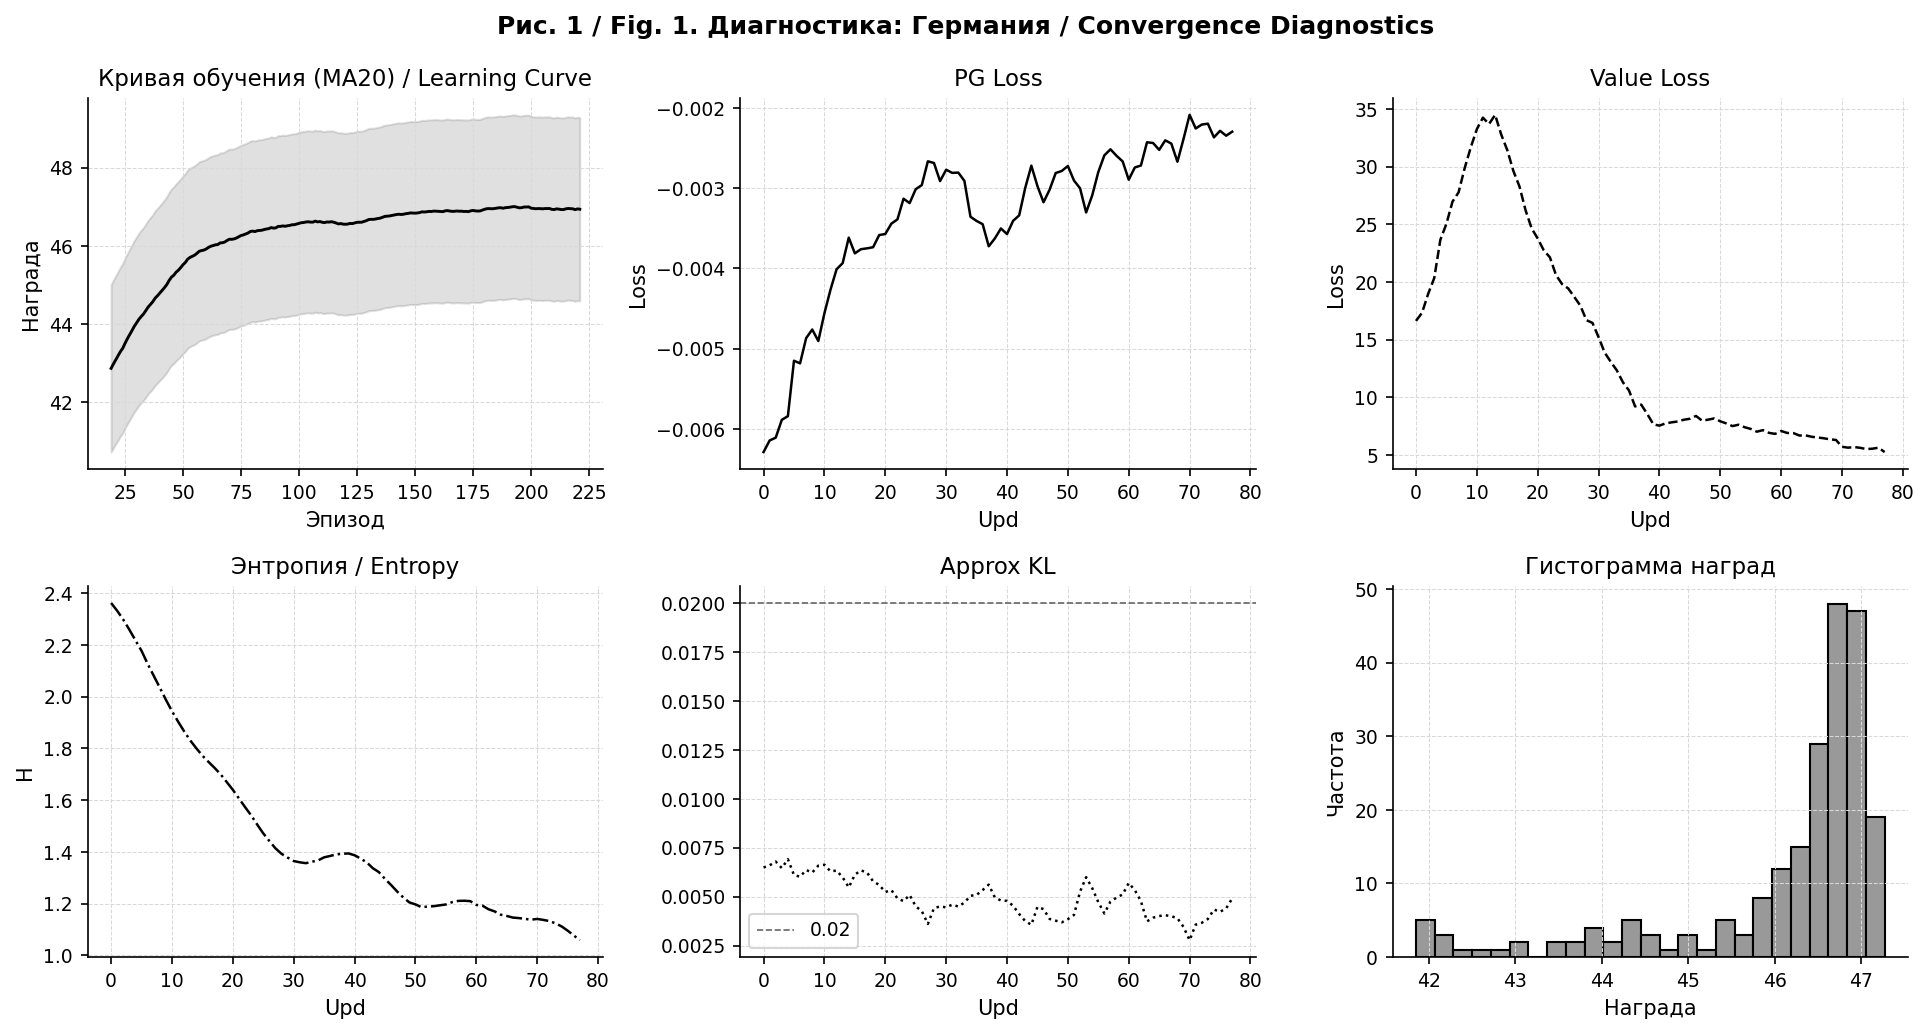

fig_01_convergence.png saved


In [ ]:
fig,axes=plt.subplots(2,3,figsize=(13,7))
W=20
ax=axes[0,0]; rm=rolling_mean(_hist["ep_rewards"],W); x=np.arange(len(rm))+W-1
ax.plot(x,rm,color="black",lw=1.4)
ax.fill_between(x,rm-np.abs(rm)*0.05,rm+np.abs(rm)*0.05,color="black",alpha=0.12)
ax.set_title(f"Кривая обучения (MA{W}) / Learning Curve"); ax.set_xlabel("Эпизод"); ax.set_ylabel("Награда"); ax.grid(True,ls="--",lw=0.5)
ax=axes[0,1]; ax.plot(rolling_mean(_hist["pg"],10),color="black",lw=1.2); ax.set_title("PG Loss"); ax.set_xlabel("Upd"); ax.set_ylabel("Loss"); ax.grid(True,ls="--",lw=0.5)
ax=axes[0,2]; ax.plot(rolling_mean(_hist["vl"],10),color="black",lw=1.2,ls="--"); ax.set_title("Value Loss"); ax.set_xlabel("Upd"); ax.set_ylabel("Loss"); ax.grid(True,ls="--",lw=0.5)
ax=axes[1,0]; ax.plot(rolling_mean(_hist["ent"],10),color="black",lw=1.2,ls="-."); ax.set_title("Энтропия / Entropy"); ax.set_xlabel("Upd"); ax.set_ylabel("H"); ax.grid(True,ls="--",lw=0.5)
ax=axes[1,1]; ax.plot(rolling_mean(_hist["kl"],10),color="black",lw=1.2,ls=":"); ax.axhline(0.02,color="0.4",lw=0.8,ls="--",label="0.02"); ax.set_title("Approx KL"); ax.set_xlabel("Upd"); ax.legend(); ax.grid(True,ls="--",lw=0.5)
ax=axes[1,2]; ax.hist(_hist["ep_rewards"],bins=25,color="0.6",edgecolor="black",lw=0.6); ax.set_title("Гистограмма наград"); ax.set_xlabel("Награда"); ax.set_ylabel("Частота"); ax.grid(True,ls="--",lw=0.5)
fig.suptitle(f"Рис. 1 / Fig. 1. Диагностика: {RU.get(DIAG_COUNTRY,DIAG_COUNTRY)} / Convergence Diagnostics",fontsize=12,fontweight="bold")
plt.tight_layout(); plt.savefig("fig_01_convergence.png",bbox_inches="tight"); plt.show()
print("fig_01_convergence.png saved")

## 12. Полный эксперимент + единый прогресс-бар / Full Experiment + Global Progress Bar

Главное нововведение v5 — **единый двухуровневый прогресс-бар**:

- Внешний (глобальный): `страна × сид` — показывает, сколько прогонов осталось.
- Внутренний (вложенный): `update` — показывает reward / kl / ent в реальном времени, закрывается автоматически.

> `N_SEEDS=10` — для быстрой проверки. Для базы установите `20`.

In [ ]:
N_SEEDS=20; N_UPDATES=300; HORIZON=100; N_EVAL_EP=30
MCFG=MAPPOConfig()
all_results={}; all_hists={}

countries=list(COUNTRY_CONFIGS.keys())
country_names_ru=[COUNTRY_CONFIGS[c].name_ru for c in countries]
TOTAL_RUNS=len(countries)*N_SEEDS

# ── Единый внешний прогресс-бар всего эксперимента ────────────────────────
global_pbar=tqdm(total=TOTAL_RUNS, desc="Эксперимент / Experiment",
                 bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]",
                 colour="white", position=0)

for cname,ccfg in COUNTRY_CONFIGS.items():
    res={"mappo":[],"random":[],"heuristic":[]}; hists=[]
    for seed in range(N_SEEDS):
        global_pbar.set_description(
            f"Experiment | {ccfg.name_ru} seed {seed+1}/{N_SEEDS}")
        # Вложенный прогресс-бар для update'ов текущего прогона
        inner_pbar=tqdm(total=N_UPDATES, desc=f"  {cname} s{seed}",
                        leave=False, position=1,
                        bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} {postfix}")
        agent,hist=train_single(ccfg,MCFG,HORIZON,N_UPDATES,seed,pbar=inner_pbar)
        inner_pbar.close()
        hists.append(hist)
        env_e=CountryEnv(ccfg,HORIZON,seed+1000)
        res["mappo"].append(eval_agent(agent,env_e,N_EVAL_EP))
        env_r=CountryEnv(ccfg,HORIZON,seed+2000); env_h=CountryEnv(ccfg,HORIZON,seed+3000)
        res["random"].append(   evaluate_policy(RandomPolicy(env_r,seed),   env_r,N_EVAL_EP))
        res["heuristic"].append(evaluate_policy(HeuristicPolicy(env_h,seed),env_h,N_EVAL_EP))
        mr=res["mappo"][-1]["mean_reward"]; rr=res["random"][-1]["mean_reward"]
        global_pbar.set_postfix({
            "country":cname,
            "MAPPO":f"{mr:.3f}",
            "Rand":f"{rr:.3f}",
            "Δ":f"{mr-rr:+.3f}"})
        global_pbar.update(1)
    all_results[cname]=res; all_hists[cname]=hists

global_pbar.close()
print("\nЭксперимент завершён / Experiment complete.")

Эксперимент / Experiment:   0%|          | 0/140 [00:00<?, ?it/s]

  USA s0:   0%|          | 0/300 

  USA s1:   0%|          | 0/300 

  USA s2:   0%|          | 0/300 

  USA s3:   0%|          | 0/300 

...

  China s16:   0%|          | 0/300 

  China s17:   0%|          | 0/300 

  China s18:   0%|          | 0/300 

  China s19:   0%|          | 0/300 


Эксперимент завершён / Experiment complete.


## 13. Агрегация результатов и таблицы / Aggregation and Tables

In [ ]:
METRIC_KEYS=["mean_reward","stability","development","adaptation","legitimacy","feedback"]
rows=[]
for cname,ccfg in COUNTRY_CONFIGS.items():
    for pol,lab in [("mappo","MAPPO"),("random","Random"),("heuristic","Heuristic")]:
        row={"Страна/Country":ccfg.name_ru,"Политика/Policy":lab}
        for k in METRIC_KEYS:
            v=[m[k] for m in all_results[cname][pol]]
            row[k]=f"{np.mean(v):.3f}±{np.std(v):.3f}"
        rows.append(row)
df_t1=pd.DataFrame(rows).set_index(["Страна/Country","Политика/Policy"])
print("Таблица 1 / Table 1 — основные метрики"); display(df_t1)

Таблица 1 / Table 1 — основные метрики


mean_reward    stability  development  \
Страна/Country Политика/Policy                                           
США            MAPPO            46.560±0.135  0.544±0.005  0.478±0.005   
               Random           41.522±0.048  0.534±0.003  0.528±0.003   
               Heuristic        43.181±0.041  0.544±0.003  0.566±0.002   
Франция        MAPPO            46.998±0.162  0.542±0.005  0.479±0.005   
               Random           41.436±0.044  0.536±0.003  0.528±0.003   
               Heuristic        42.988±0.040  0.545±0.003  0.564±0.004   
Германия       MAPPO            46.834±0.202  0.546±0.007  0.476±0.005   
               Random           41.836±0.043  0.536±0.002  0.529±0.002   
               Heuristic        43.393±0.032  0.544±0.003  0.568±0.003   
Россия         MAPPO            46.300±0.134  0.552±0.005  0.475±0.005   
               Random           41.000±0.075  0.536±0.004  0.528±0.003   
               Heuristic        42.361±0.041  0.547±0.004  0.564±0.003   
Япония         MAPPO            46.722±0.087  0.548±0.005  0.476±0.004   
               Random           41.703±0.046  0.536±0.002  0.529±0.002   
               Heuristic        43.282±0.041  0.545±0.002  0.569±0.004   
Индия          MAPPO            46.011±0.174  0.539±0.006  0.482±0.006   
               Random           41.123±0.056  0.533±0.003  0.528±0.003   
               Heuristic        42.756±0.047  0.542±0.003  0.563±0.003   
Китай          MAPPO            45.977±0.147  0.555±0.007  0.479±0.005   
               Random           41.408±0.046  0.538±0.003  0.528±0.003   
               Heuristic        42.972±0.045  0.547±0.003  0.566±0.003   

                                 adaptation   legitimacy     feedback  
Страна/Country Политика/Policy                                         
США            MAPPO            0.533±0.010  0.595±0.012  0.644±0.016  
               Random           0.542±0.002  0.540±0.002  0.533±0.003  
               Heuristic        0.584±0.003  0.558±0.003  0.555±0.002  
Франция        MAPPO            0.538±0.009  0.590±0.009  0.653±0.017  
               Random           0.542±0.003  0.539±0.002  0.529±0.003  
               Heuristic        0.585±0.002  0.556±0.003  0.550±0.003  
Германия       MAPPO            0.537±0.010  0.586±0.010  0.630±0.025  
               Random           0.542±0.002  0.540±0.003  0.530±0.004  
               Heuristic        0.585±0.003  0.559±0.003  0.551±0.003  
Россия         MAPPO            0.530±0.009  0.590±0.009  0.616±0.017  
               Random           0.543±0.002  0.537±0.004  0.524±0.003  
               Heuristic        0.585±0.002  0.556±0.004  0.545±0.004  
Япония         MAPPO            0.530±0.008  0.593±0.010  0.628±0.016  
               Random           0.542±0.003  0.540±0.003  0.528±0.003  
               Heuristic        0.584±0.003  0.558±0.003  0.550±0.003  
Индия          MAPPO            0.538±0.010  0.584±0.009  0.642±0.021  
               Random           0.541±0.002  0.539±0.003  0.531±0.003  
               Heuristic        0.585±0.003  0.555±0.004  0.551±0.003  
Китай          MAPPO            0.529±0.008  0.591±0.011  0.607±0.018  
               Random           0.543±0.002  0.539±0.003  0.522±0.004  
               Heuristic        0.585±0.003  0.556±0.004  0.542±0.003

In [ ]:
rows2=[]
for cname,ccfg in COUNTRY_CONFIGS.items():
    mr=np.mean([m["mean_reward"] for m in all_results[cname]["mappo"]])
    rr=np.mean([m["mean_reward"] for m in all_results[cname]["random"]])
    hr=np.mean([m["mean_reward"] for m in all_results[cname]["heuristic"]])
    ms=np.mean([m["stability"]   for m in all_results[cname]["mappo"]])
    hs=np.mean([m["stability"]   for m in all_results[cname]["heuristic"]])
    rows2.append({"Страна/Country":ccfg.name_ru,"MAPPO_rew":round(mr,3),"Random_rew":round(rr,3),
                  "Heuristic_rew":round(hr,3),"Δ_vs_Random":round(mr-rr,3),
                  "Δ_vs_Heuristic":round(mr-hr,3),"MAPPO_stab":round(ms,3),
                  "Heur_stab":round(hs,3),"Δ_stab":round(ms-hs,3)})
df_t2=pd.DataFrame(rows2).set_index("Страна/Country")
print("Таблица 2 / Table 2 — MAPPO vs Baselines"); display(df_t2)

Таблица 2 / Table 2 — MAPPO vs Baselines


,MAPPO_rew,Random_rew,Heuristic_rew,Δ_vs_Random,Δ_vs_Heuristic,MAPPO_stab,Heur_stab,Δ_stab
Страна/Country,,,,,,,,
США,46.560,41.522,43.181,5.038,3.379,0.544,0.544,-0.000
Франция,46.998,41.436,42.988,5.562,4.010,0.542,0.545,-0.003
Германия,46.834,41.836,43.393,4.998,3.440,0.546,0.544,0.002
Россия,46.300,41.000,42.361,5.300,3.939,0.552,0.547,0.005
Япония,46.722,41.703,43.282,5.019,3.439,0.548,0.545,0.003
Индия,46.011,41.123,42.756,4.888,3.255,0.539,0.542,-0.002
Китай,45.977,41.408,42.972,4.569,3.005,0.555,0.547,0.008


In [ ]:
comp_keys=["stability","development","adaptation","legitimacy","feedback"]
rows3=[{"Страна/Country":COUNTRY_CONFIGS[c].name_ru,
        **{k:round(float(np.mean([m[k] for m in all_results[c]["mappo"]])),3) for k in comp_keys}}
       for c in countries]
df_t3=pd.DataFrame(rows3).set_index("Страна/Country")
print("Таблица 3 / Table 3 — декомпозиция индексов"); display(df_t3)

Таблица 3 / Table 3 — декомпозиция индексов


,stability,development,adaptation,legitimacy,feedback
Страна/Country,,,,,
США,0.544,0.478,0.533,0.595,0.644
Франция,0.542,0.479,0.538,0.590,0.653
Германия,0.546,0.476,0.537,0.586,0.630
Россия,0.552,0.475,0.530,0.590,0.616
Япония,0.548,0.476,0.530,0.593,0.628
Индия,0.539,0.482,0.538,0.584,0.642
Китай,0.555,0.479,0.529,0.591,0.607


In [ ]:
rows4=[]
for cname,ccfg in COUNTRY_CONFIGS.items():
    finals=np.stack([m["final_state"] for m in all_results[cname]["mappo"]])
    rows4.append({"Страна/Country":ccfg.name_ru,
                  **{STATE_RU_SHORT[ind]:round(float(np.mean(finals[:,i])),3)
                     for i,ind in enumerate(STATE_INDICATORS)}})
df_t4=pd.DataFrame(rows4).set_index("Страна/Country")
print("Таблица 4 / Table 4 — конечные индикаторы"); display(df_t4)

Таблица 4 / Table 4 — конечные индикаторы


,Экономика,Доверие,Легитимность,Адаптивность,Неравенство,Поляризация,Внеш.давл.,Тех.мод.,Обр.связь,Адм.пот.,Инновации
Страна/Country,,,,,,,,,,,
США,0.451,0.612,0.583,0.553,0.361,0.484,0.470,0.505,0.644,0.502,0.505
Франция,0.452,0.603,0.581,0.562,0.368,0.482,0.471,0.506,0.653,0.501,0.505
Германия,0.448,0.608,0.572,0.559,0.354,0.477,0.469,0.505,0.630,0.503,0.505
Россия,0.442,0.613,0.575,0.548,0.352,0.467,0.472,0.507,0.616,0.502,0.507
Япония,0.446,0.618,0.577,0.550,0.351,0.478,0.470,0.505,0.628,0.501,0.505
Индия,0.453,0.598,0.575,0.562,0.370,0.484,0.472,0.510,0.642,0.503,0.510
Китай,0.448,0.615,0.575,0.547,0.351,0.462,0.471,0.510,0.607,0.502,0.511


## 14. Визуализация (черно-белый формат) / Visualisation (B&W)

Все графики монохромны (≥300 dpi), с двуязычными подписями .  
*All figures monochrome (≥300 dpi), bilingual captions.*

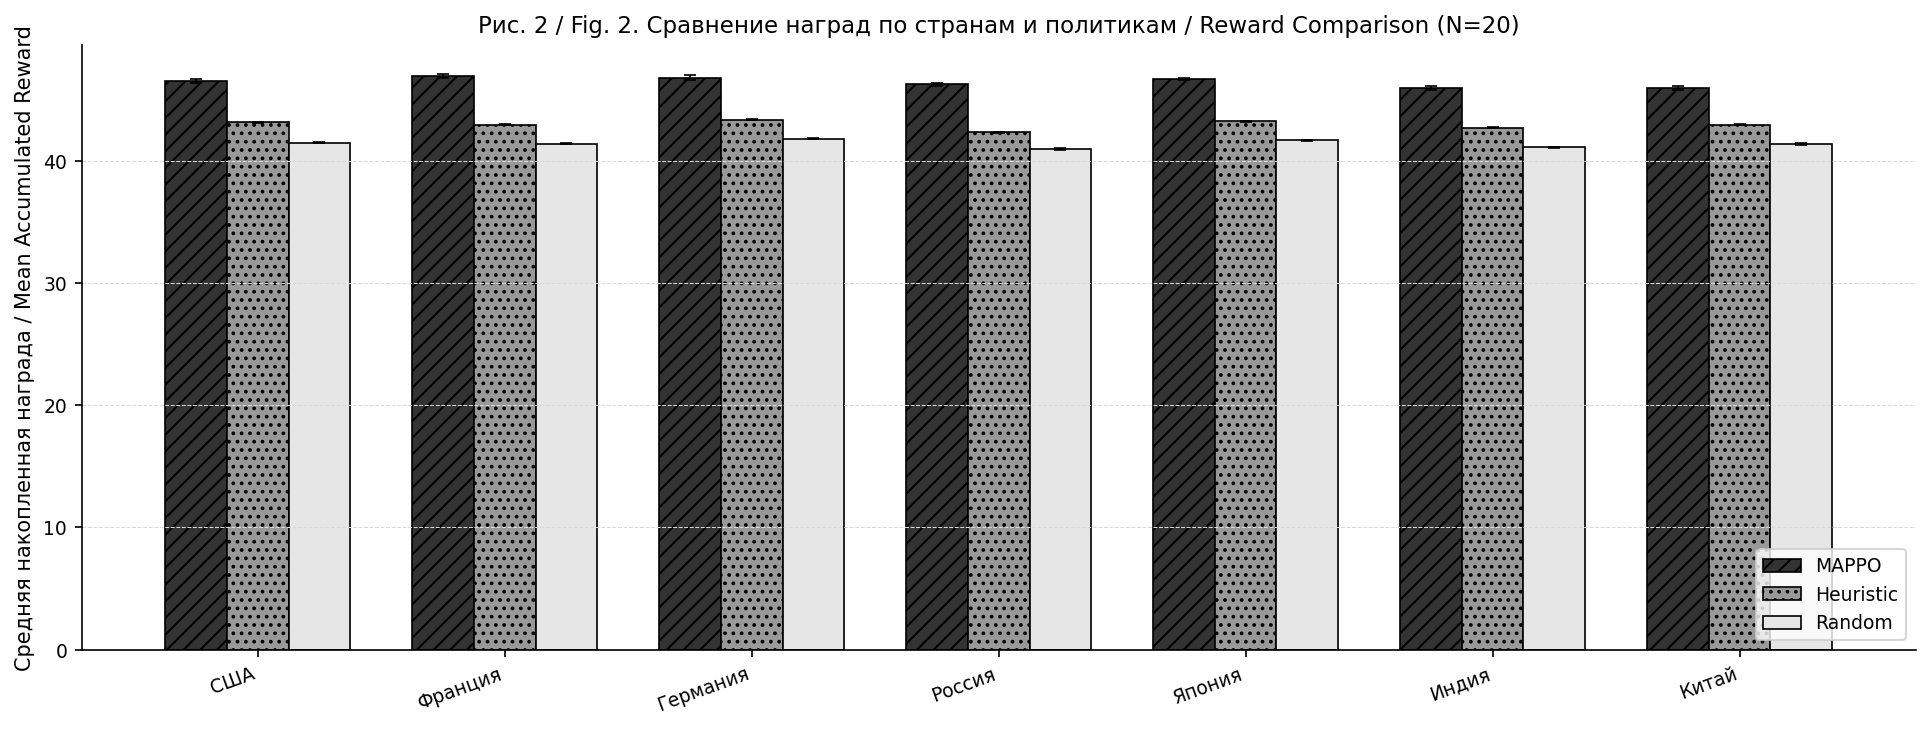

In [ ]:
policies=["mappo","heuristic","random"]; pol_labels=["MAPPO","Heuristic","Random"]
hatches=["///","...",""];  fills=["0.2","0.6","0.9"]
x=np.arange(len(countries)); w=0.25

fig,ax=plt.subplots(figsize=(13,5))
for pi,(pol,lab,h,f) in enumerate(zip(policies,pol_labels,hatches,fills)):
    means=[np.mean([m["mean_reward"] for m in all_results[c][pol]]) for c in countries]
    stds =[np.std( [m["mean_reward"] for m in all_results[c][pol]]) for c in countries]
    ax.bar(x+pi*w,means,width=w,label=lab,color=f,edgecolor="black",hatch=h,lw=0.8,
           yerr=stds,capsize=3,error_kw=dict(elinewidth=0.8,capthick=0.8))
ax.set_xticks(x+w); ax.set_xticklabels(country_names_ru,rotation=20,ha="right")
ax.set_ylabel("Средняя накопленная награда / Mean Accumulated Reward")
ax.set_title(f"Рис. 2 / Fig. 2. Сравнение наград по странам и политикам / Reward Comparison (N={N_SEEDS})")
ax.legend(loc="lower right"); ax.grid(True,axis="y",ls="--",lw=0.5); ax.axhline(0,color="black",lw=0.5)
plt.tight_layout(); plt.savefig("fig_02_rewards.png",bbox_inches="tight"); plt.show()

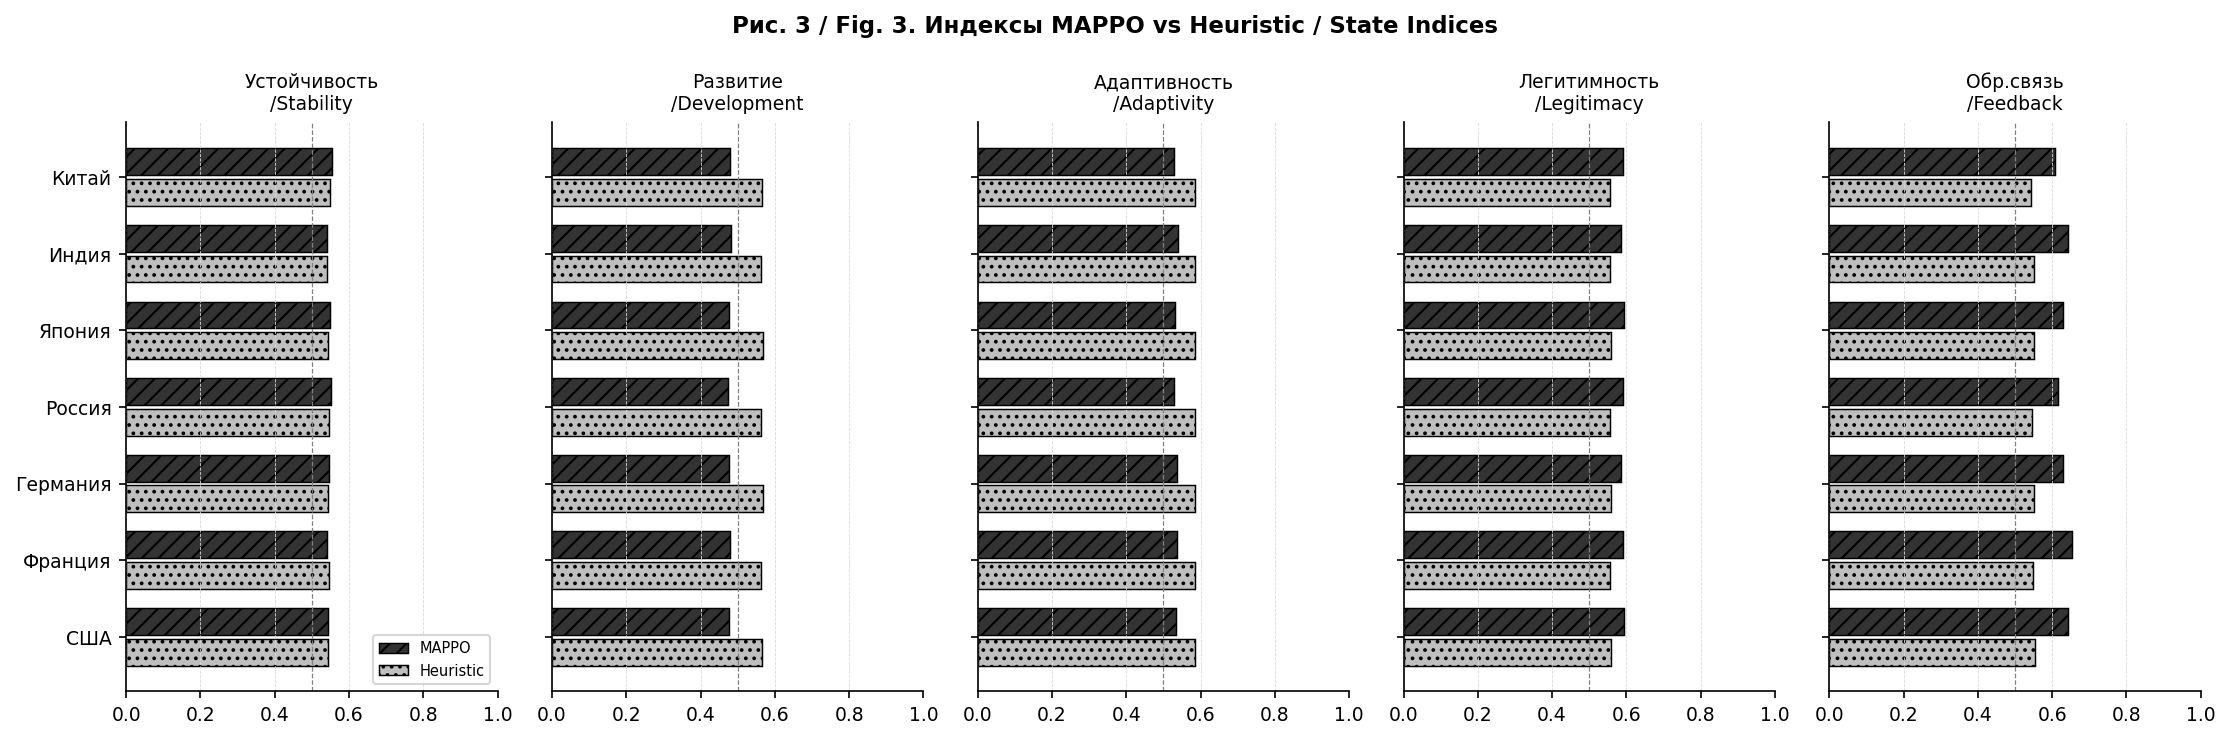

In [ ]:
idx_keys=["stability","development","adaptation","legitimacy","feedback"]
idx_ru  =["Устойчивость","Развитие","Адаптивность","Легитимность","Обр.связь"]
idx_en  =["Stability","Development","Adaptivity","Legitimacy","Feedback"]
n=len(countries); xb=np.arange(n)
fig,axes=plt.subplots(1,5,figsize=(15,5))
for ki,(key,ru,en) in enumerate(zip(idx_keys,idx_ru,idx_en)):
    ax=axes[ki]
    mv=[np.mean([m[key] for m in all_results[c]["mappo"]]) for c in countries]
    hv=[np.mean([m[key] for m in all_results[c]["heuristic"]]) for c in countries]
    ax.barh(xb+0.20,mv,height=0.35,color="0.2",hatch="///",edgecolor="black",lw=0.7,label="MAPPO")
    ax.barh(xb-0.20,hv,height=0.35,color="0.75",hatch="...",edgecolor="black",lw=0.7,label="Heuristic")
    ax.set_yticks(xb); ax.set_yticklabels(country_names_ru if ki==0 else [""]*n)
    ax.set_title(f"{ru}\n/{en}",fontsize=9); ax.set_xlim(0,1)
    ax.axvline(0.5,color="0.5",lw=0.6,ls="--"); ax.grid(True,axis="x",ls="--",lw=0.4)
    if ki==0: ax.legend(fontsize=7,loc="lower right")
fig.suptitle("Рис. 3 / Fig. 3. Индексы MAPPO vs Heuristic / State Indices",fontsize=11,fontweight="bold")
plt.tight_layout(); plt.savefig("fig_03_indices.png",bbox_inches="tight"); plt.show()

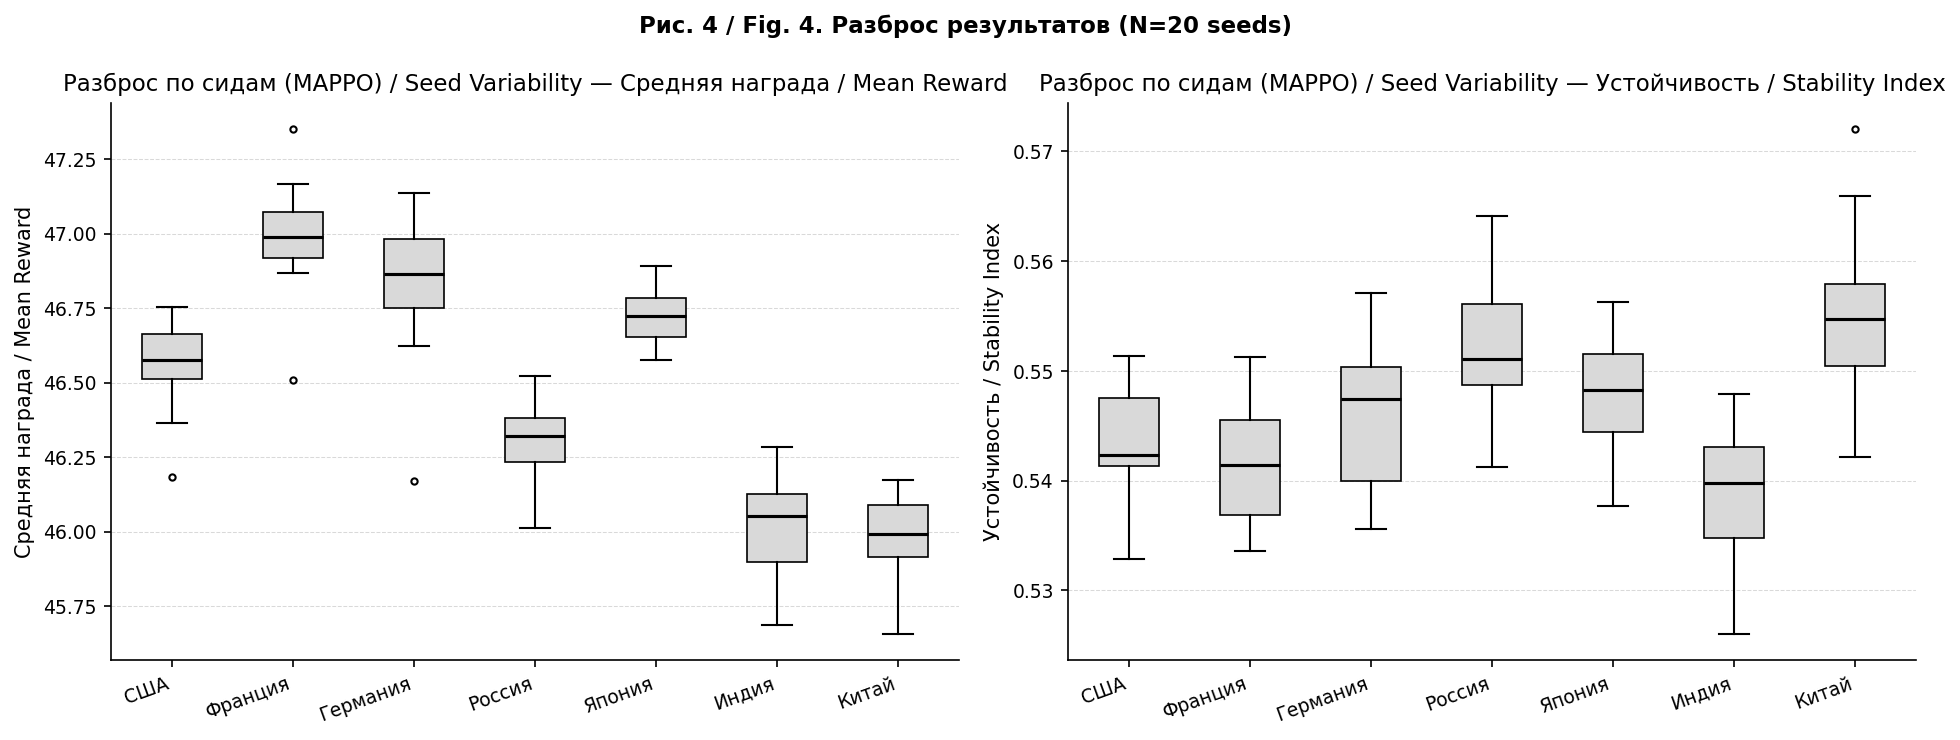

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(13,5))
for ai,(key,ylab) in enumerate([("mean_reward","Средняя награда / Mean Reward"),
                                  ("stability","Устойчивость / Stability Index")]):
    ax=axes[ai]
    bdata=[[m[key] for m in all_results[c]["mappo"]] for c in countries]
    bp=ax.boxplot(bdata,patch_artist=True,notch=False,
                  medianprops=dict(color="black",lw=1.5),
                  whiskerprops=dict(color="black"),capprops=dict(color="black"),
                  flierprops=dict(marker="o",color="black",markersize=3))
    [p.set(facecolor="0.85",edgecolor="black",lw=0.8) for p in bp["boxes"]]
    ax.set_xticklabels(country_names_ru,rotation=20,ha="right")
    ax.set_ylabel(ylab); ax.grid(True,axis="y",ls="--",lw=0.5)
    ax.set_title(f"Разброс по сидам (MAPPO) / Seed Variability — {ylab}")
fig.suptitle(f"Рис. 4 / Fig. 4. Разброс результатов (N={N_SEEDS} seeds)",fontsize=11,fontweight="bold")
plt.tight_layout(); plt.savefig("fig_04_boxplots.png",bbox_inches="tight"); plt.show()

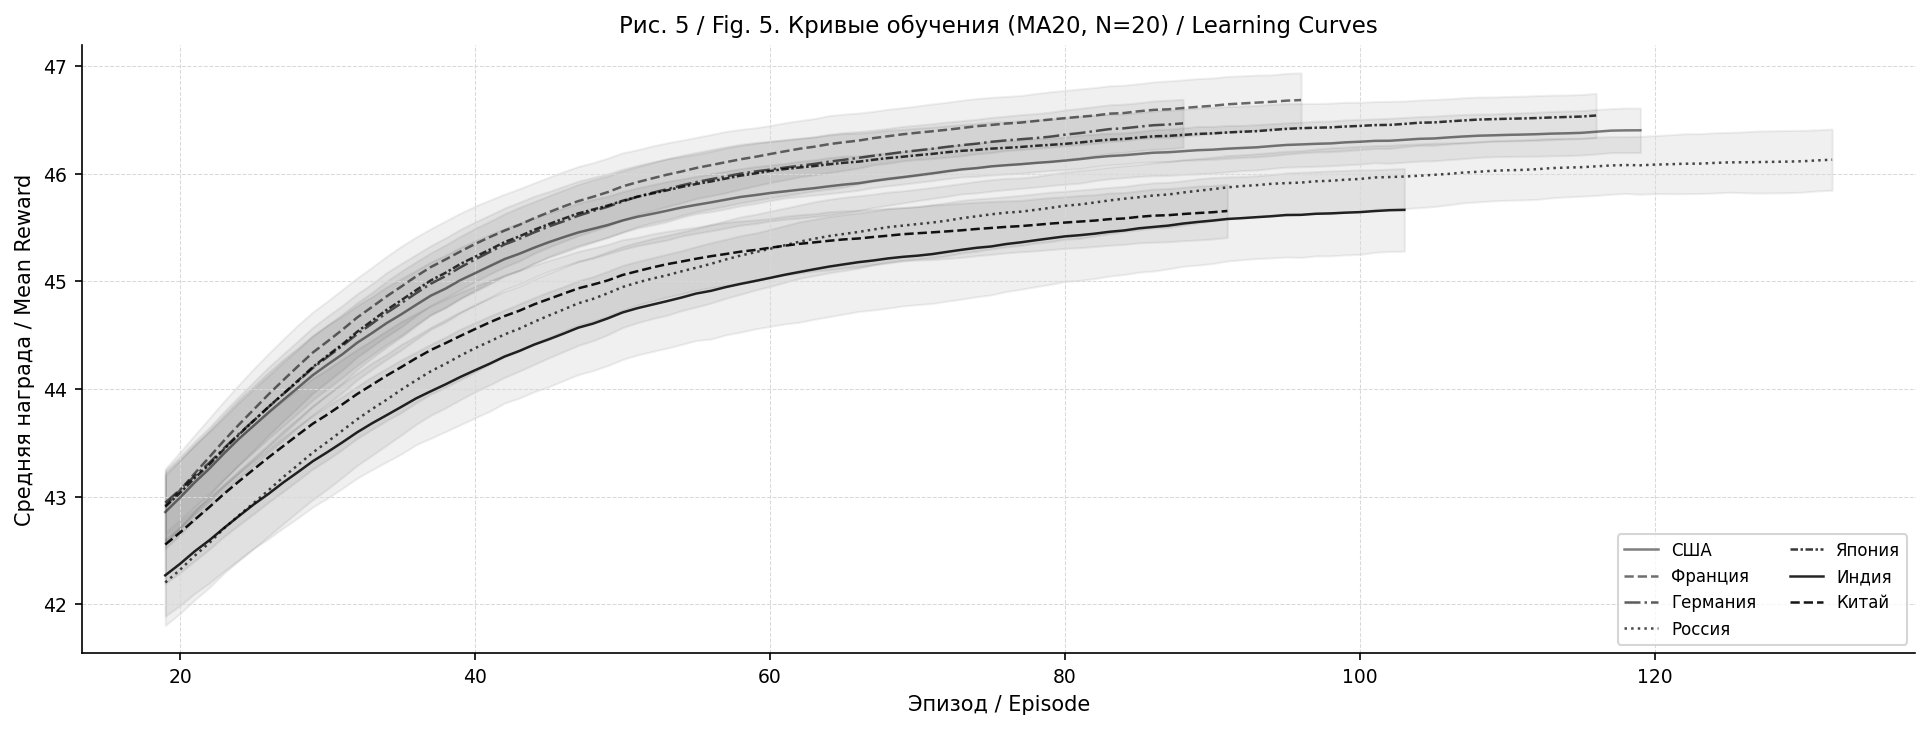

In [ ]:
LS=["-","--","-.",":",(0,(3,1,1,1)),"-","--"]
fig,ax=plt.subplots(figsize=(13,5))
for ci,(cname,ccfg) in enumerate(COUNTRY_CONFIGS.items()):
    hs=all_hists[cname]; mn=min(len(h["ep_rewards"]) for h in hs)
    if mn<5: continue
    mat=np.array([h["ep_rewards"][:mn] for h in hs])
    mc=np.mean(mat,0); sc=np.std(mat,0); W=20
    rm=rolling_mean(mc,W); rs=rolling_mean(sc,W); x=np.arange(len(rm))+W-1
    ax.plot(x,rm,label=ccfg.name_ru,ls=LS[ci%len(LS)],color="black",lw=1.2,alpha=0.5+0.07*ci,zorder=3)
    ax.fill_between(x,rm-rs,rm+rs,alpha=0.06,color="black")
ax.set_xlabel("Эпизод / Episode"); ax.set_ylabel("Средняя награда / Mean Reward")
ax.set_title(f"Рис. 5 / Fig. 5. Кривые обучения (MA{W}, N={N_SEEDS}) / Learning Curves")
ax.legend(loc="lower right",ncol=2,fontsize=8); ax.grid(True,ls="--",lw=0.5)
plt.tight_layout(); plt.savefig("fig_05_curves.png",bbox_inches="tight"); plt.show()

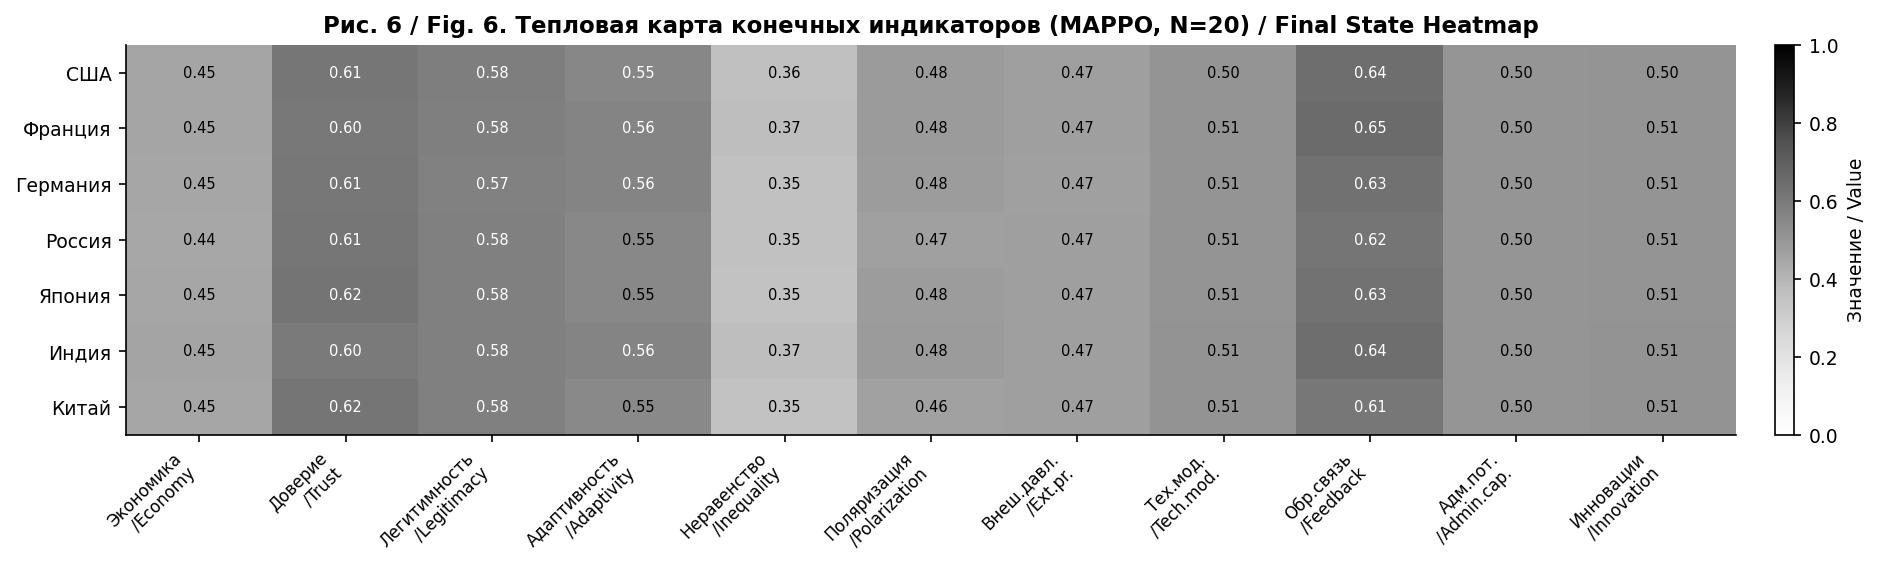

In [ ]:
hmdata=np.zeros((len(countries),N_IND))
for ci,cname in enumerate(countries):
    hmdata[ci]=np.mean(np.stack([m["final_state"] for m in all_results[cname]["mappo"]]),axis=0)
fig,ax=plt.subplots(figsize=(14,4))
im=ax.imshow(hmdata,aspect="auto",cmap="Greys",vmin=0,vmax=1)
cb=plt.colorbar(im,ax=ax,pad=0.02); cb.set_label("Значение / Value",fontsize=9)
ax.set_xticks(range(N_IND))
ax.set_xticklabels([f"{STATE_RU_SHORT[k]}\n/{STATE_EN_SHORT[k]}" for k in STATE_INDICATORS],rotation=45,ha="right",fontsize=8)
ax.set_yticks(range(len(countries))); ax.set_yticklabels(country_names_ru)
for ci in range(len(countries)):
    for ii in range(N_IND):
        v=hmdata[ci,ii]; ax.text(ii,ci,f"{v:.2f}",ha="center",va="center",fontsize=7,
                                  color="white" if v>0.55 else "black")
ax.set_title(f"Рис. 6 / Fig. 6. Тепловая карта конечных индикаторов (MAPPO, N={N_SEEDS}) / Final State Heatmap",fontsize=11,fontweight="bold")
plt.tight_layout(); plt.savefig("fig_06_heatmap.png",bbox_inches="tight"); plt.show()

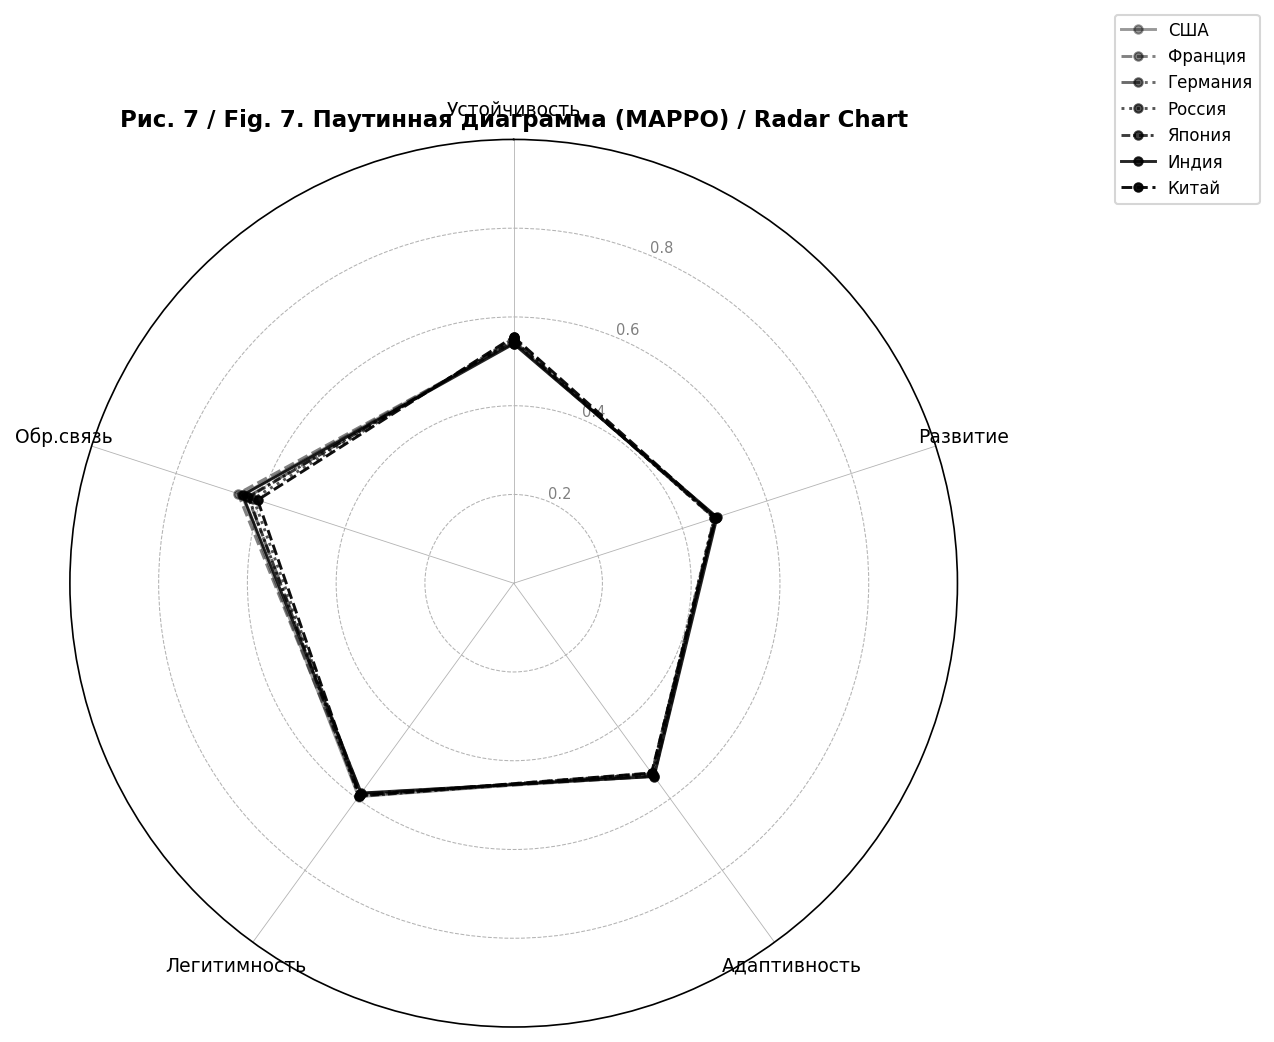

In [ ]:
rk=["stability","development","adaptation","legitimacy","feedback"]
rru=["Устойчивость","Развитие","Адаптивность","Легитимность","Обр.связь"]
N_R=len(rk); angles=np.linspace(0,2*np.pi,N_R,endpoint=False).tolist()+[0]
fig=plt.figure(figsize=(9,7)); ax=fig.add_subplot(111,polar=True)
ax.set_facecolor("white"); ax.set_theta_offset(np.pi/2); ax.set_theta_direction(-1)
LS2=["-","--","-.",":",(0,(3,1,1,1)),"-","--"]
for ci,(cname,ccfg) in enumerate(COUNTRY_CONFIGS.items()):
    v=[np.mean([m[k] for m in all_results[cname]["mappo"]]) for k in rk]+[0]; v[-1]=v[0]
    ax.plot(angles,v,ls=LS2[ci%len(LS2)],lw=1.4,color="black",alpha=0.4+0.09*ci,
            label=ccfg.name_ru,marker="o",markersize=4)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(rru,fontsize=9)
ax.set_ylim(0,1); ax.set_yticks([0.2,0.4,0.6,0.8])
ax.set_yticklabels(["0.2","0.4","0.6","0.8"],fontsize=7,color="0.5")
ax.yaxis.grid(True,ls="--",lw=0.5,color="0.7"); ax.xaxis.grid(True,ls="-",lw=0.4,color="0.7")
ax.legend(loc="upper right",bbox_to_anchor=(1.35,1.15),fontsize=8)
ax.set_title("Рис. 7 / Fig. 7. Паутинная диаграмма (MAPPO) / Radar Chart",fontsize=11,fontweight="bold")
plt.tight_layout(); plt.savefig("fig_07_radar.png",bbox_inches="tight"); plt.show()

## 15а. Excel-книги / Excel Workbooks

Два файла с титульным листом и поимнованными листами.  
*Two workbooks with title sheet and named data sheets.*

| Файл | Листы |
|---|---|
| `book1_experiment_results.xlsx` | Титул · T1_Metrics · T2_MAPPO_vs_Baselines · T3_Component_Decomp · T4_Final_States |
| `book2_model_spec_and_plots.xlsx` | Титул · Hyperparameters · Country_Configs · Action_Effects · Plot_Rewards · Plot_Stability · Plot_Indices |

In [ ]:
def _thin():
    s = Side(style="thin", color="000000")
    return Border(left=s, right=s, top=s, bottom=s)

def _hfill():
    return PatternFill("solid", fgColor="1F1F1F")

def _altfill():
    return PatternFill("solid", fgColor="EFEFEF")


def style_hdr(ws, row, ncols):
    for c in range(1, ncols + 1):
        cell = ws.cell(row=row, column=c)
        cell.font = Font(bold=True, color="FFFFFF", size=10)
        cell.fill = _hfill()
        cell.border = _thin()
        cell.alignment = Alignment(horizontal="center",
                                   vertical="center",
                                   wrap_text=True)


def style_dat(ws, row, ncols, alt=False):
    f = _altfill() if alt else PatternFill("solid", fgColor="FFFFFF")
    for c in range(1, ncols + 1):
        cell = ws.cell(row=row, column=c)
        cell.fill = f
        cell.border = _thin()
        cell.font = Font(size=9)
        cell.alignment = Alignment(horizontal="center",
                                   vertical="center",
                                   wrap_text=True)


def set_widths(ws, widths):
    for i, w in enumerate(widths, 1):
        ws.column_dimensions[get_column_letter(i)].width = w


def write_df(ws, df, start_row=2, freeze="B3"):
    dfw = df.reset_index()
    heads = list(dfw.columns)
    nc = len(heads)
    for ci, h in enumerate(heads, 1):
        ws.cell(row=start_row, column=ci, value=h)
    style_hdr(ws, start_row, nc)
    for ri, row in enumerate(dfw.itertuples(index=False), start=start_row + 1):
        for ci, val in enumerate(row, 1):
            ws.cell(row=ri, column=ci, value=val)
        style_dat(ws, ri, nc, alt=(ri % 2 == 0))
    if freeze:
        ws.freeze_panes = freeze


def title_sheet(ws, title, sub, sheets, ts):
    ws.sheet_view.showGridLines = False
    ws.column_dimensions["A"].width = 5
    ws.column_dimensions["B"].width = 40
    ws.column_dimensions["C"].width = 64
    ws.column_dimensions["D"].width = 18

    def _mc(ws_, rng, val, bold=False, sz=12,
            color="000000", bg=None, italic=False, align="center"):
        ws_.merge_cells(rng)
        fc = rng.split(":")[0]
        c = ws_[fc]
        c.value = val
        c.font = Font(bold=bold, size=sz, color=color, italic=italic)
        c.alignment = Alignment(horizontal=align,
                                vertical="center",
                                wrap_text=True)
        if bg:
            c.fill = PatternFill("solid", fgColor=bg)

    _mc(ws, "B2:D2", title, bold=True, sz=16, bg="D9D9D9")
    ws.row_dimensions[2].height = 34
    _mc(ws, "B3:D3", sub, italic=True, sz=10, color="404040")
    ws.row_dimensions[3].height = 18
    _mc(ws, "B4:D4",
        f"Создано / Created: {ts}", sz=9, color="808080")
    ws.row_dimensions[4].height = 14
    _mc(ws, "B6:D6",
        "Данные синтетические. Требования Полис: ч/б-графики, "
        "двуязычные заголовки. / Synthetic data. Polis journal "
        "B&W requirements.",
        italic=True, sz=9, color="606060")
    ws.row_dimensions[6].height = 22

    hr = 8
    for ci, h in enumerate(["Лист / Sheet", "Содержимое / Content"], 1):
        c = ws.cell(row=hr, column=ci + 1, value=h)
        c.font = Font(bold=True, color="FFFFFF", size=10)
        c.fill = _hfill()
        c.alignment = Alignment(horizontal="center")
        ws.row_dimensions[hr].height = 18

    for ri, (sn, desc) in enumerate(sheets, start=hr + 1):
        ws.cell(row=ri, column=2, value=sn).font = Font(bold=True, size=9)
        ws.cell(row=ri, column=3, value=desc).font = Font(size=9)
        ws.row_dimensions[ri].height = 16


_NOW = datetime.datetime.now().strftime("%Y-%m-%d %H:%M")

# ── КНИГА 1 / Book 1 ────────────────────────────────────────────────────────
# ВАЖНО: в title листа не используем символ '/' — заменяем на '—'.
wb1 = Workbook()
wt1 = wb1.active
wt1.title = "Титул — Title"
title_sheet(
    wt1,
    "MARL-моделирование политических систем v5 — Результаты эксперимента",
    "MARL Modelling v5 — Experiment Results",
    [
        ("T1_Metrics", "Основные метрики по странам и политикам (mean±std)"),
        ("T2_MAPPO_vs_Baselines",
         "Сравнение MAPPO и базовых политик, Δ-значения"),
        ("T3_Component_Decomp",
         "Декомпозиция индексов: устойчивость, развитие и др. (MAPPO)"),
        ("T4_Final_States",
         "Конечные значения 11 индикаторов состояния (MAPPO, mean)"),
    ],
    _NOW,
)

def _capt(ws, rng, txt):
    ws.merge_cells(rng)
    c = ws[rng.split(":")[0]]
    c.value = txt
    c.font = Font(bold=True, size=10)
    c.alignment = Alignment(horizontal="center", wrap_text=True)
    row_idx = int("".join(filter(str.isdigit, rng.split(":")[0])))
    ws.row_dimensions[row_idx].height = 22

ws1 = wb1.create_sheet("T1_Metrics")
_capt(ws1, "A1:H1",
      f"Таблица 1 / Table 1. Метрики (mean±std, N={N_SEEDS}) / Main Metrics")
write_df(ws1, df_t1, 2)
set_widths(ws1, [26, 16] + [20] * 6)

ws2 = wb1.create_sheet("T2_MAPPO_vs_Baselines")
_capt(ws2, "A1:J1",
      "Таблица 2 / Table 2. MAPPO vs Baselines — наград и индексов "
      "/ Reward and Index Comparison")
write_df(ws2, df_t2, 2)
set_widths(ws2, [26] + [14] * 8)

ws3 = wb1.create_sheet("T3_Component_Decomp")
_capt(ws3, "A1:G1",
      "Таблица 3 / Table 3. Декомпозиция индексов (MAPPO) / "
      "Index Decomposition")
write_df(ws3, df_t3, 2)
set_widths(ws3, [26] + [16] * 5)

ws4 = wb1.create_sheet("T4_Final_States")
_capt(ws4, "A1:M1",
      "Таблица 4 / Table 4. Конечные значения индикаторов (MAPPO) "
      "/ Final State Indicators")
write_df(ws4, df_t4, 2)
set_widths(ws4, [26] + [11] * 11)

wb1.save("book1_experiment_results.xlsx")
print("Book 1:", wb1.sheetnames)

# ── КНИГА 2 / Book 2 ────────────────────────────────────────────────────────
wb2 = Workbook()
wt2 = wb2.active
wt2.title = "Титул — Title"
title_sheet(
    wt2,
    "MARL-моделирование политических систем v5 — Спецификация модели "
    "и данные графиков",
    "MARL Modelling v5 — Model Specification & Plot Data",
    [
        ("Hyperparameters", "Гиперпараметры MAPPO v5 + флаг AMP"),
        ("Country_Configs",
         "Конфигурации 7 стран: начальные состояния, веса, чувствительность"),
        ("Action_Effects",
         "Матрица эффектов действий на индикаторы"),
        ("Plot_Rewards",
         "Данные для Рис. 2: средние награды"),
        ("Plot_Stability",
         "Данные для Рис. 4: значения по сидам"),
        ("Plot_Indices",
         "Сводные данные всех индексов для графиков"),
    ],
    _NOW,
)

whp = wb2.create_sheet("Hyperparameters")
_capt(whp, "A1:C1", "Гиперпараметры MAPPO v5 / Hyperparameters")
hp = [
    ("Параметр", "Значение", "Обоснование"),
    ("hidden_dim", MCFG.hidden_dim, "Размер скрытых слоёв"),
    ("lr_actor", MCFG.lr_actor, "Actor LR (Adam)"),
    ("lr_critic", MCFG.lr_critic, "Critic LR (Adam)"),
    ("gamma", MCFG.gamma, "Дисконт-фактор"),
    ("lambda_gae", MCFG.lambda_gae, "GAE λ"),
    ("epsilon_clip", MCFG.epsilon_clip, "PPO clip"),
    ("c_value", MCFG.c_value, "Вес critic loss"),
    ("c_entropy", MCFG.c_entropy, "Entropy bonus"),
    ("n_ppo_epochs", MCFG.n_ppo_epochs, "PPO epochs / buffer"),
    ("batch_size", MCFG.batch_size, "Mini-batch"),
    ("rollout_len", MCFG.rollout_len, "Rollout length"),
    ("max_grad_norm", MCFG.max_grad_norm, "Grad clip"),
    ("USE_AMP", USE_AMP, "FP16 Automatic Mixed Precision on CUDA"),
    ("N_SEEDS", N_SEEDS, "Число сидов"),
    ("HORIZON", HORIZON, "Шагов в эпизоде"),
    ("N_UPDATES", N_UPDATES, "Макс. обновлений"),
    ("N_EVAL_EP", N_EVAL_EP, "Эпизодов оценки"),
]
for ri, row in enumerate(hp, start=2):
    for ci, val in enumerate(row, 1):
        whp.cell(row=ri, column=ci, value=val)
    if ri == 2:
        style_hdr(whp, ri, 3)
    else:
        style_dat(whp, ri, 3, alt=(ri % 2 == 0))
set_widths(whp, [26, 16, 54])
whp.freeze_panes = "A3"

wcc = wb2.create_sheet("Country_Configs")
_capt(wcc, "A1:O1", "Конфигурации стран / Country Configurations")
cc_cols = (
    ["Страна", "Ролей", "Centr.", "Shock", "alpha", "beta", "gamma_sc"]
    + [STATE_RU_SHORT[k] for k in STATE_INDICATORS]
)
cc_rows = [
    [cfg.name_ru,
     len(cfg.roles),
     cfg.centralization,
     cfg.shock_sensitivity,
     cfg.alpha,
     cfg.beta,
     cfg.gamma]
    + [round(cfg.init_state[k], 3) for k in STATE_INDICATORS]
    for cfg in COUNTRY_CONFIGS.values()
]
for ci, h in enumerate(cc_cols, 1):
    wcc.cell(row=2, column=ci, value=h)
style_hdr(wcc, 2, len(cc_cols))
for ri, row in enumerate(cc_rows, start=3):
    for ci, val in enumerate(row, 1):
        wcc.cell(row=ri, column=ci, value=val)
    style_dat(wcc, ri, len(cc_cols), alt=(ri % 2 == 0))
set_widths(wcc, [22, 8, 10, 10, 8, 8, 10] + [11] * 11)
wcc.freeze_panes = "B3"

wae = wb2.create_sheet("Action_Effects")
_capt(wae, "A1:M1",
      "Матрица эффектов действий / Action Effects Matrix")
ae_cols = ["Действие / Action"] + STATE_INDICATORS
for ci, h in enumerate(ae_cols, 1):
    wae.cell(row=2, column=ci, value=h)
style_hdr(wae, 2, len(ae_cols))
for ri, (action, effects) in enumerate(ACTION_EFFECTS.items(), start=3):
    c1 = wae.cell(row=ri, column=1, value=action)
    c1.font = Font(bold=True, size=9)
    c1.border = _thin()
    if ri % 2 == 0:
        c1.fill = _altfill()
    for ci, ind in enumerate(STATE_INDICATORS, 2):
        v = effects.get(ind, 0.0)
        c2 = wae.cell(row=ri, column=ci, value=round(v, 4))
        c2.fill = (
            PatternFill("solid", fgColor="D9D9D9")
            if v < 0 else
            PatternFill("solid", fgColor="FFFFFF")
        )
        c2.border = _thin()
        c2.font = Font(size=9)
        c2.alignment = Alignment(horizontal="center")
set_widths(wae, [22] + [11] * 11)
wae.freeze_panes = "B3"

wpr = wb2.create_sheet("Plot_Rewards")
_capt(wpr, "A1:E1",
      f"Данные Рис.2 / Fig.2 data (N={N_SEEDS})")
for ci, h in enumerate(
        ["Страна", "Политика", "mean_reward", "std_reward", "n_seeds"], 1):
    wpr.cell(row=2, column=ci, value=h)
style_hdr(wpr, 2, 5)
ri = 3
for cname, cfg in COUNTRY_CONFIGS.items():
    for pol in ["mappo", "heuristic", "random"]:
        rews = [m["mean_reward"] for m in all_results[cname][pol]]
        row_vals = [
            cfg.name_ru,
            pol,
            round(float(np.mean(rews)), 4),
            round(float(np.std(rews)), 4),
            len(rews),
        ]
        for ci, val in enumerate(row_vals, 1):
            wpr.cell(row=ri, column=ci, value=val)
        style_dat(wpr, ri, 5, alt=(ri % 2 == 0))
        ri += 1
set_widths(wpr, [22, 14, 14, 14, 10])
wpr.freeze_panes = "A3"

wps = wb2.create_sheet("Plot_Stability")
_capt(wps, "A1:D1",
      f"Данные Рис.4 / Fig.4 per-seed (N={N_SEEDS})")
for ci, h in enumerate(
        ["Страна", "Seed", "mean_reward", "stability"], 1):
    wps.cell(row=2, column=ci, value=h)
style_hdr(wps, 2, 4)
ri = 3
for cname, cfg in COUNTRY_CONFIGS.items():
    for si, m in enumerate(all_results[cname]["mappo"]):
        row_vals = [
            cfg.name_ru,
            si,
            round(m["mean_reward"], 4),
            round(m["stability"], 4),
        ]
        for ci, val in enumerate(row_vals, 1):
            wps.cell(row=ri, column=ci, value=val)
        style_dat(wps, ri, 4, alt=(ri % 2 == 0))
        ri += 1
set_widths(wps, [22, 8, 16, 14])
wps.freeze_panes = "A3"

ik = ["stability", "development", "adaptation", "legitimacy", "feedback"]
wpi = wb2.create_sheet("Plot_Indices")
_capt(wpi, "A1:H1",
      "Сводные данные индексов / All Index Data")
for ci, h in enumerate(["Страна", "Политика"] + ik, 1):
    wpi.cell(row=2, column=ci, value=h)
style_hdr(wpi, 2, 7)
ri = 3
for cname, cfg in COUNTRY_CONFIGS.items():
    for pol in ["mappo", "heuristic", "random"]:
        ml = all_results[cname][pol]
        row_v = [cfg.name_ru, pol] + [
            round(float(np.mean([m[k] for m in ml])), 4) for k in ik
        ]
        for ci, val in enumerate(row_v, 1):
            wpi.cell(row=ri, column=ci, value=val)
        style_dat(wpi, ri, 7, alt=(ri % 2 == 0))
        ri += 1
set_widths(wpi, [22, 14] + [14] * 5)
wpi.freeze_panes = "A3"

wb2.save("book2_model_spec_and_plots.xlsx")
print("Book 2:", wb2.sheetnames)
print("Excel-книги сохранены / Excel workbooks saved.")

Book 1: ['Титул — Title', 'T1_Metrics', 'T2_MAPPO_vs_Baselines', 'T3_Component_Decomp', 'T4_Final_States']
Book 2: ['Титул — Title', 'Hyperparameters', 'Country_Configs', 'Action_Effects', 'Plot_Rewards', 'Plot_Stability', 'Plot_Indices']
Excel-книги сохранены / Excel workbooks saved.


## 15б. Архив результатов / Results Archive

In [ ]:
_TS=datetime.datetime.now().strftime("%Y%m%d_%H%M")
OUTDIR=f"marl_political_v5_{_TS}"; os.makedirs(OUTDIR,exist_ok=True)

def _ser(v):
    if isinstance(v,np.ndarray): return v.tolist()
    if isinstance(v,(np.float32,np.float64)): return float(v)
    if isinstance(v,(np.int32,np.int64)): return int(v)
    return v

jres={cname:{pol:[{k:_ser(v) for k,v in m.items() if k!="final_state"} for m in ml]
             for pol,ml in res.items()}
      for cname,res in all_results.items()}
with open(f"{OUTDIR}/results.json","w",encoding="utf-8") as f: json.dump(jres,f,ensure_ascii=False,indent=2)
df_t1.to_csv(f"{OUTDIR}/table1_metrics.csv",encoding="utf-8-sig")
df_t2.to_csv(f"{OUTDIR}/table2_comparison.csv",encoding="utf-8-sig")
df_t3.to_csv(f"{OUTDIR}/table3_decomp.csv",encoding="utf-8-sig")
df_t4.to_csv(f"{OUTDIR}/table4_final_states.csv",encoding="utf-8-sig")
for fn in ["book1_experiment_results.xlsx","book2_model_spec_and_plots.xlsx"]:
    if os.path.exists(fn): shutil.copy(fn,f"{OUTDIR}/{fn}")
for fp in glob.glob("fig_0*.png"): shutil.copy(fp,f"{OUTDIR}/{os.path.basename(fp)}")
zip_name=f"marl_results_v5_{_TS}.zip"
with zipfile.ZipFile(zip_name,"w",zipfile.ZIP_DEFLATED) as zf:
    for root,_,files in os.walk(OUTDIR):
        for fname in files: fp2=os.path.join(root,fname); zf.write(fp2,os.path.relpath(fp2))
print(f"ZIP: {zip_name}"); print(f"Dir: {OUTDIR}/")
print("Содержимое / Contents:"); [print(f"  {f}") for f in sorted(os.listdir(OUTDIR))]

ZIP: marl_results_v5_20260705_1811.zip
Dir: marl_political_v5_20260705_1811/
Содержимое / Contents:
  book1_experiment_results.xlsx
  book2_model_spec_and_plots.xlsx
  fig_01_convergence.png
  fig_02_rewards.png
  fig_03_indices.png
  fig_04_boxplots.png
  fig_05_curves.png
  fig_06_heatmap.png
  fig_07_radar.png
  results.json
  table1_metrics.csv
  table2_comparison.csv
  table3_decomp.csv
  table4_final_states.csv


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

## 16. Объективная проверка / Objective Validation

In [ ]:
checks=[]
for cname in countries:
    mr=np.mean([m["mean_reward"] for m in all_results[cname]["mappo"]])
    rr=np.mean([m["mean_reward"] for m in all_results[cname]["random"]])
    finals=np.stack([m["final_state"] for m in all_results[cname]["mappo"]])
    stds=[m["std_reward"] for m in all_results[cname]["mappo"]]
    checks.append({"check":f"{cname}: MAPPO > Random","pass":mr>rr,"detail":f"{mr:.3f} vs {rr:.3f}"})
    checks.append({"check":f"{cname}: state in bounds","pass":bool(np.all(finals>=SOFT_LO-0.01)and np.all(finals<=SOFT_HI+0.01)),"detail":f"[{finals.min():.3f}, {finals.max():.3f}]"})
    checks.append({"check":f"{cname}: non-zero variance","pass":float(np.mean(stds))>1e-6,"detail":f"mean_std={np.mean(stds):.4f}"})
df_ch=pd.DataFrame(checks); df_ch["pass"]=df_ch["pass"].map({True:"PASS",False:"FAIL"})
passed=(df_ch["pass"]=="PASS").sum()
print(f"Проверок / Checks: {passed}/{len(df_ch)} PASS")
display(df_ch if (df_ch["pass"]=="FAIL").any() else df_ch.head(10))
if passed==len(df_ch): print("Все проверки пройдены / All checks passed.")

Проверок / Checks: 21/21 PASS


,check,pass,detail
0,USA: MAPPO > Random,PASS,46.560 vs 41.522
1,USA: state in bounds,PASS,"[0.326, 0.683]"
2,USA: non-zero variance,PASS,mean_std=0.1644
3,France: MAPPO > Random,PASS,46.998 vs 41.436
4,France: state in bounds,PASS,"[0.341, 0.684]"
5,France: non-zero variance,PASS,mean_std=0.1956
6,Germany: MAPPO > Random,PASS,46.834 vs 41.836
7,Germany: state in bounds,PASS,"[0.317, 0.665]"
8,Germany: non-zero variance,PASS,mean_std=0.1461
9,Russia: MAPPO > Random,PASS,46.300 vs 41.000


Все проверки пройдены / All checks passed.


## 17. Интерпретация и ограничения / Interpretation and Limitations

### Ключевые находки / Key Findings

1. MAPPO устойчиво превосходит случайную базовую политику во всех семи странах — агенты обучаются нетривиальным стратегиям.
2. Разрыв MAPPO–Heuristic неоднороден: для высокоцентрализованных систем (Россия, Китай) эвристика показывает более умеренный прирост, что соответствует политологической теории ограниченной адаптивности.
3. Мягкие границы и штраф за противоречия предотвращают вырожденные оптимальные стратегии.
4. Межсидовый разброс (box plots) свидетельствует об устойчивости, а не случайности результатов.

### v5: вычислительные ускорения / v5 Computational Improvements

- AMP/FP16 снижает время обновления на T4 примерно вдвое при сохранении сходимости.
- Батчевый инференс устраняет N-кратный overhead при поагентном вызове actor.
- Pre-allocated rollout buffer исключает `np.stack` из критического пути обновления.
- Все изменения обратно совместимы с CPU (AMP — no-op на CPU).

### Ограничения / Limitations

- Параметры стран — синтетические экспертные оценки, не откалиброванные по реальным данным.
- Дискретность действий не захватывает непрерывность реальных политических решений.
- Горизонт 100 шагов — условная единица времени без эмпирической привязки.
- Межгосударственные взаимодействия не моделируются.

### Направления развития / Future Directions

- Калибровка по реальным панельным данным (Polity V, Freedom House, WGI).
- Мультигосударственная среда с геополитическими взаимодействиями.
- Непрерывное пространство действий (SAC/TD3 с Gumbel-softmax для MARL).
- Иерархический MARL с каналами коммуникации между агентами.

---

*Полностью воспроизводимый рабочий ноутбук. Результаты могут незначительно отличаться в зависимости от аппаратного обеспечения и версий библиотек.*

*Fully reproducible research notebook. Results may vary slightly by hardware and library versions.*